In [1120]:
import pandas as pd

# Limpieza y Procesamiento de Datos

## 1.

In [1121]:
df_jugadores = pd.read_csv("jugadores.csv") # Cargar jugadores.csv en un DataFrame
df_jugadores # Mostrar las primeras filas del DataFrame para verificar su contenido

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,21.9,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back


## 2.

### a)
Todas las selecciones tienen 26 jugadores, excepto Austria, Canadá y Jordania que tienen 25

In [1122]:
df_jugadores["seleccion"].nunique() # Cuántas selecciones distintas hay

48

In [1123]:
selecciones = df_jugadores.groupby("seleccion")
selecciones.size().unique() # Cuántos jugadores hay por selección

array([26, 25])

In [1124]:
selecciones.size()[selecciones.size() == 25]

seleccion
Austria    25
Canada     25
Jordan     25
dtype: int64

### b)

In [1125]:
df_jugadores["club"].nunique()

449

In [1126]:
cantidad_clubes = df_jugadores.groupby("club").size()
cantidad_clubes[cantidad_clubes>=10].sort_values()

club
Fenerbahçe             10
Milan                  10
Real Madrid            10
PSV Eindhoven          10
Slavia Prague          10
Galatasaray            11
Liverpool              11
Borussia Dortmund      11
Atlético Madrid        12
Manchester United      12
Crystal Palace         12
Al-Hilal               12
Barcelona              15
Paris Saint-Germain    16
Arsenal                16
Bayern Munich          18
Manchester City        19
dtype: int64

### c)
El rango etario dominante en las primeras cinco selecciones del ranking FIFA es entre 24 y 30 años

In [1127]:
rango_etario = lambda edad : "A" if edad < 24 else ("B" if edad <= 30 else "C")
df_jugadores["rango_etario"] = [rango_etario(edad) for edad in df_jugadores["edad"]]
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper,C
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back,B
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward,B
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back,C


In [1128]:
top_cinco_ranking_fifa = ["Argentina", "Francia", "España", "Inglaterra", "Brasil"]
df_top_cinco = df_jugadores[df_jugadores["seleccion"].isin(top_cinco_ranking_fifa)]
df_top_cinco.groupby("rango_etario").size().sort_values(ascending=False)

rango_etario
B    15
C     8
A     3
dtype: int64

## 3.
Eliminamos todas las variables del grupo playing_time_, ya que no abarcan el 60% de cobertura

In [1129]:
variables = ["standard_playing_time_mp", "shooting_90s", "misc_performance_fls", "playing_time_starts_starts"]
df_variables = df_jugadores[variables]
df_variables.notna().sum()/len(df_jugadores) * 100

standard_playing_time_mp      73.975904
shooting_90s                  74.056225
misc_performance_fls          71.405622
playing_time_starts_starts    38.232932
dtype: float64

In [1130]:
variables_playing_time = [col for col in df_jugadores.columns if col.startswith("playing_time_")]
df_jugadores.drop(columns=variables_playing_time, inplace=True)
df_jugadores.columns.size

82

## 4.
Las variables que estén en NAN las podemos poner en 0, ya que se basan en tiros y si el jugador no realizó ninguno cualquier ratio debería dar 0

In [1131]:
variables_shooting = [col for col in df_jugadores.columns if col.startswith("shooting_")]
df_jugadores.fillna({col: 0 for col in variables_shooting}, inplace=True) # Reemplazar los valores faltantes por 0
print(df_jugadores[variables_shooting].isna().sum()) # Verificar que los valores faltantes hayan sido reemplazados

shooting_90s                    0
shooting_standard_gls           0
shooting_standard_sh            0
shooting_standard_sot           0
shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
shooting_standard_g_per_sh      0
shooting_standard_g_per_sot     0
shooting_standard_pk            0
shooting_standard_pkatt         0
dtype: int64


In [1132]:
col_ratios = ["shooting_standard_sh", "shooting_standard_sot","shooting_standard_sotpct","shooting_standard_sh_per_90","shooting_standard_sot_per_90"]
df_jugadores[col_ratios].isna().sum()

shooting_standard_sh            0
shooting_standard_sot           0
shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
dtype: int64

In [1133]:
df_jugadores[col_ratios] = df_jugadores[col_ratios].fillna(0)
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper,C
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back,B
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward,B
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back,C


## 5.
La baja cobertura de las variables keeper_ se debe a que solo aplica a aquellos jugadores que ocupen esta posición. Esto se puede arreglar reemplazando los NA por 0 excepto aquellos donde exista alguna variable similar en otro grupo (como partidos como titular o minutos jugados).

In [1134]:
copia = df_jugadores.copy() # Hago una copia del DataFrame para no modificar el original
variables_keeper = [col for col in copia.columns if col.startswith("keeper_")]
copia.fillna({col: 0 for col in variables_keeper}, inplace=True) # Reemplazar los valores faltantes por 0
print(copia[variables_keeper].isna().sum()) # Verificar que los valores faltantes hayan sido reemplazados

keeper_playing_time_mp          0
keeper_playing_time_starts      0
keeper_playing_time_min         0
keeper_90s                      0
keeper_performance_ga           0
keeper_performance_ga90         0
keeper_performance_sota         0
keeper_performance_saves        0
keeper_performance_savepct      0
keeper_performance_w            0
keeper_performance_d            0
keeper_performance_l            0
keeper_performance_cs           0
keeper_performance_cspct        0
keeper_penalty_kicks_pkatt      0
keeper_penalty_kicks_pka        0
keeper_penalty_kicks_pksv       0
keeper_penalty_kicks_pkm        0
keeper_penalty_kicks_savepct    0
keeper_playing_time_90s         0
dtype: int64


## 6.

In [1135]:
porcentajes = (df_jugadores.notna().sum() / len(df_jugadores) * 100).sort_values() # Porcentaje de valores no faltantes por variable
porcentajes[porcentajes < 60] # Variables con menos del 60% de valores no faltantes

misc_performance_pkwon          0.000000
misc_performance_pkcon          0.000000
keeper_90s                      2.811245
keeper_playing_time_90s         4.417671
keeper_penalty_kicks_savepct    6.184739
keeper_performance_savepct      6.666667
keeper_performance_sota         6.746988
keeper_performance_saves        6.746988
keeper_performance_cspct        7.148594
keeper_performance_w            7.228916
keeper_performance_d            7.228916
keeper_playing_time_mp          7.228916
keeper_performance_ga           7.228916
keeper_playing_time_starts      7.228916
keeper_playing_time_min         7.228916
keeper_performance_ga90         7.228916
keeper_penalty_kicks_pka        7.228916
keeper_penalty_kicks_pkatt      7.228916
keeper_penalty_kicks_pksv       7.228916
keeper_penalty_kicks_pkm        7.228916
keeper_performance_l            7.228916
keeper_performance_cs           7.228916
dtype: float64

In [1136]:
# Elimino las variables misc_performance_pkwon, misc_performance_pkcon, y las de keeper_ ya que tienen < 60% de cobertura.
df_jugadores_limpia = df_jugadores.drop(columns=["misc_performance_pkwon", "misc_performance_pkcon"] + variables_keeper)
df_jugadores_limpia.reset_index(drop=True, inplace=True) # Reiniciar el índice del DataFrame
df_jugadores_limpia.columns.size

60

In [1137]:
df_jugadores_limpia.isna().sum(axis=1).value_counts().sort_index() # Cantidad de filas valores faltantes

0     873
1       8
2       7
6      33
19      1
30      1
32    294
33      4
34     24
Name: count, dtype: int64

In [1138]:
df_jugadores_limpia.drop(df_jugadores_limpia[df_jugadores_limpia.isna().sum(axis=1)>30].index, inplace=True) # Elimino filas con más de 30 valores faltantes (mas de la mitad de las variables)
df_jugadores_limpia.reset_index(drop=True, inplace=True) # Reseteo el índice del DataFrame
df_jugadores_limpia

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,5.0,0.0,0.0,1.0,0.0,0.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,22.0,0.0,4.0,40.0,17.0,0.0,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,28.0,1.0,22.0,44.0,24.0,0.0,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,10.0,0.0,6.0,20.0,15.0,0.0,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,42.0,1.0,209.0,39.0,35.0,0.0,CZE,7000000.0,Right-Back,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,1239,Panama,20,MF,Aníbal Godoy,1990-02-10,36,159,4,San Diego FC,...,37.0,0.0,3.0,16.0,14.0,0.0,PAN,200000.0,Defensive Midfield,C
919,1240,Panama,21,MF,César Yanis,1996-01-28,30,56,5,Cobresal,...,36.0,4.0,39.0,24.0,13.0,0.0,PAN,250000.0,Right Winger,B
920,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,8.0,0.0,0.0,0.0,0.0,1.0,PAN,350000.0,Goalkeeper,C
921,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,14.0,2.0,29.0,6.0,8.0,0.0,PAN,7000000.0,Right-Back,B


In [1139]:
df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

misc_performance_crdr              1
misc_performance_2crdy             1
misc_90s                           1
misc_performance_og                1
misc_performance_crdy              1
standard_playing_time_mp           2
standard_playing_time_min          2
standard_playing_time_starts       2
standard_performance_crdr          2
standard_performance_pk            2
standard_performance_pkatt         2
standard_playing_time_90s          2
standard_performance_ast           2
standard_performance_gls           2
standard_performance_gpa           2
standard_performance_g-pk          2
standard_performance_crdy          2
standard_per_90_minutes_gpa        2
standard_per_90_minutes_gls        2
standard_per_90_minutes_ast        2
standard_per_90_minutes_gpa-pk     2
standard_per_90_minutes_g-pk       2
nation_fbref                       3
nat3                               3
posicion_tm                        6
valor_mercado_eur                 14
misc_performance_fld              34
m

In [1140]:
# Reemplazo los NA en misc_ y standard_ por 0, pues son variables que miden cantidades o proporciones, y el NA puede ser interpretado como 0.
variables_misc_performance = [col for col in df_jugadores_limpia.columns if col.startswith("misc_")]
variables_standard = [col for col in df_jugadores_limpia.columns if col.startswith("standard_")]
df_jugadores_limpia.fillna({col: 0 for col in variables_misc_performance + variables_standard}, inplace=True)
df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

nation_fbref          3
nat3                  3
posicion_tm           6
valor_mercado_eur    14
dtype: int64

In [1141]:
# Veo en qué jugadores faltan los valores de nation_fbref, nat3 y posicion_tm
df_jugadores_limpia[df_jugadores_limpia[["nation_fbref", "nat3", "posicion_tm"]].isna().sum(axis=1)>0][["seleccion", "posicion", "cod_fifa", "nation_fbref", "nat3", "posicion_tm"]]

,seleccion,posicion,cod_fifa,nation_fbref,nat3,posicion_tm
73,South Korea,MF,KOR,KOR,KOR,NaN
86,South Korea,MF,KOR,NaN,NaN,Central Midfield
171,Brazil,FW,BRA,BRA,BRA,NaN
253,Paraguay,MF,PAR,PAR,PAR,NaN
504,Egypt,DF,EGY,NaN,NaN,Centre-Back
524,Iran,FW,IRN,NaN,NaN,Centre-Forward
572,Saudi Arabia,MF,KSA,KSA,KSA,NaN
737,Argentina,MF,ARG,ARG,ARG,NaN
771,Jordan,FW,JOR,JOR,JOR,NaN


In [1142]:
# Relleno los valores faltantes copiando de otras variables
df_jugadores_limpia.fillna({col : df_jugadores_limpia["cod_fifa"] for col in ["nation_fbref", "nat3"]}, inplace=True)

# Reemplazo en posicion_tm por central Midfield si posicion es MF, y sino por Centre-Forward
df_jugadores_limpia["posicion_tm"] = df_jugadores_limpia["posicion_tm"].fillna(df_jugadores_limpia.apply(lambda row: "Central Midfield" if row["posicion"] == "MF" else "Centre-Forward", axis=1))

# Reemplazo los valores faltantes en valor_mercado_eur por el promedio de esta variable.
df_jugadores_limpia.fillna({"valor_mercado_eur" : df_jugadores_limpia["valor_mercado_eur"].mean()}, inplace=True)

df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

Series([], dtype: int64)

In [1143]:
print("Cantidad de jugadores: " + str(len(df_jugadores_limpia)))
print("Cantidad de variables numericas: " + str(len(df_jugadores_limpia.select_dtypes(include='number').columns)))

Cantidad de jugadores: 923
Cantidad de variables numericas: 45


## 7.

In [1144]:
selecciones_a_eliminar = df_jugadores_limpia["seleccion"].value_counts()[df_jugadores_limpia["seleccion"].value_counts()<=4].index
jugadores_a_eliminar = df_jugadores_limpia[df_jugadores_limpia["seleccion"].isin(selecciones_a_eliminar)].index
df_jugadores_limpia.drop(index=jugadores_a_eliminar, inplace=True) # Elimino los jugadores de las selecciones con 4 o menos jugadores
df_jugadores_limpia.reset_index(drop=True, inplace=True)

In [1145]:
variables_numericas = df_jugadores_limpia.select_dtypes(include='number').drop(columns=["player_id", "numero"])
variables_numericas["seleccion"] = df_jugadores_limpia["seleccion"]
variables_numericas_seleccion_promedio = variables_numericas.groupby("seleccion").mean()
df_selecciones = variables_numericas_seleccion_promedio.reset_index()
df_selecciones

,seleccion,edad,caps,goles_seleccion,standard_playing_time_mp,standard_playing_time_starts,standard_playing_time_min,standard_playing_time_90s,standard_performance_gls,standard_performance_ast,...,misc_performance_crdr,misc_performance_2crdy,misc_performance_fls,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,valor_mercado_eur
0,Algeria,26.875000,41.375000,6.500000,24.937500,20.312500,1780.875000,19.768750,3.812500,3.062500,...,0.125000,0.000000,19.437500,20.687500,3.625000,54.312500,16.437500,17.750000,0.000000,1.072500e+07
1,Argentina,29.083333,50.541667,9.041667,24.375000,20.416667,1805.625000,20.070833,3.916667,2.833333,...,0.375000,0.083333,18.333333,25.166667,2.166667,33.875000,13.750000,16.916667,0.125000,3.032051e+07
2,Australia,26.850000,25.800000,2.100000,21.950000,18.150000,1637.150000,18.185000,1.100000,0.900000,...,0.050000,0.050000,15.100000,17.700000,1.150000,25.300000,14.100000,16.950000,0.000000,1.927500e+06
3,Austria,27.869565,37.260870,4.391304,25.478261,20.260870,1800.478261,20.000000,1.956522,2.000000,...,0.173913,0.043478,16.043478,17.739130,1.521739,22.565217,16.130435,18.695652,0.043478,1.199130e+07
4,Belgium,27.115385,41.000000,8.038462,28.192308,23.923077,2124.115385,23.596154,2.500000,2.615385,...,0.076923,0.038462,19.307692,22.653846,2.269231,35.500000,16.615385,19.230769,0.076923,1.982692e+07
5,Bosnia and Herzegovina,25.733333,28.066667,6.000000,24.733333,19.066667,1684.066667,18.706667,3.533333,2.400000,...,0.200000,0.133333,20.666667,19.533333,3.466667,32.866667,12.000000,14.933333,0.200000,6.999485e+06
6,Brazil,28.652174,37.913043,6.391304,25.565217,22.956522,2013.043478,22.373913,5.173913,2.000000,...,0.521739,0.304348,24.130435,27.260870,3.347826,30.043478,12.565217,15.782609,0.043478,4.057792e+07
7,Canada,27.000000,41.142857,6.047619,20.000000,14.047619,1260.047619,13.990476,2.142857,1.380952,...,0.238095,0.142857,14.095238,19.428571,3.476190,10.238095,8.571429,10.142857,0.000000,8.711905e+06
8,Cape Verde,27.750000,29.166667,3.500000,18.833333,12.166667,1084.916667,12.050000,1.333333,1.500000,...,0.250000,0.083333,15.833333,20.583333,1.833333,33.500000,7.916667,14.750000,0.000000,2.381250e+06
9,Colombia,29.952381,44.714286,4.619048,25.523810,21.714286,1914.428571,21.280952,3.285714,2.428571,...,0.190476,0.095238,24.095238,26.190476,3.428571,31.571429,14.523810,19.904762,0.142857,1.214286e+07


# Análisis exploratorio

In [1146]:
import seaborn.objects as so

In [1147]:
df_selecciones.columns

Index(['seleccion', 'edad', 'caps', 'goles_seleccion',
       'standard_playing_time_mp', 'standard_playing_time_starts',
       'standard_playing_time_min', 'standard_playing_time_90s',
       'standard_performance_gls', 'standard_performance_ast',
       'standard_performance_gpa', 'standard_performance_g-pk',
       'standard_performance_pk', 'standard_performance_pkatt',
       'standard_performance_crdy', 'standard_performance_crdr',
       'standard_per_90_minutes_gls', 'standard_per_90_minutes_ast',
       'standard_per_90_minutes_gpa', 'standard_per_90_minutes_g-pk',
       'standard_per_90_minutes_gpa-pk', 'shooting_90s',
       'shooting_standard_gls', 'shooting_standard_sh',
       'shooting_standard_sot', 'shooting_standard_sotpct',
       'shooting_standard_sh_per_90', 'shooting_standard_sot_per_90',
       'shooting_standard_g_per_sh', 'shooting_standard_g_per_sot',
       'shooting_standard_pk', 'shooting_standard_pkatt', 'misc_90s',
       'misc_performance_crdy', 'misc

Ideas:
1. Relación entre los valores de las selecciones y su rendimiento
2. Mapa que muestre precio las selecciones, rendimiento y continente de pertenencia
3. Afecta la edad al rendimiento del equipo? cuanto?
4. No creo poder hacerla por la cantidad de info necesaria, pero sería una buena idea analizar el rendimiento de las selecciones anfitrionas respecto del resto en los mundiales

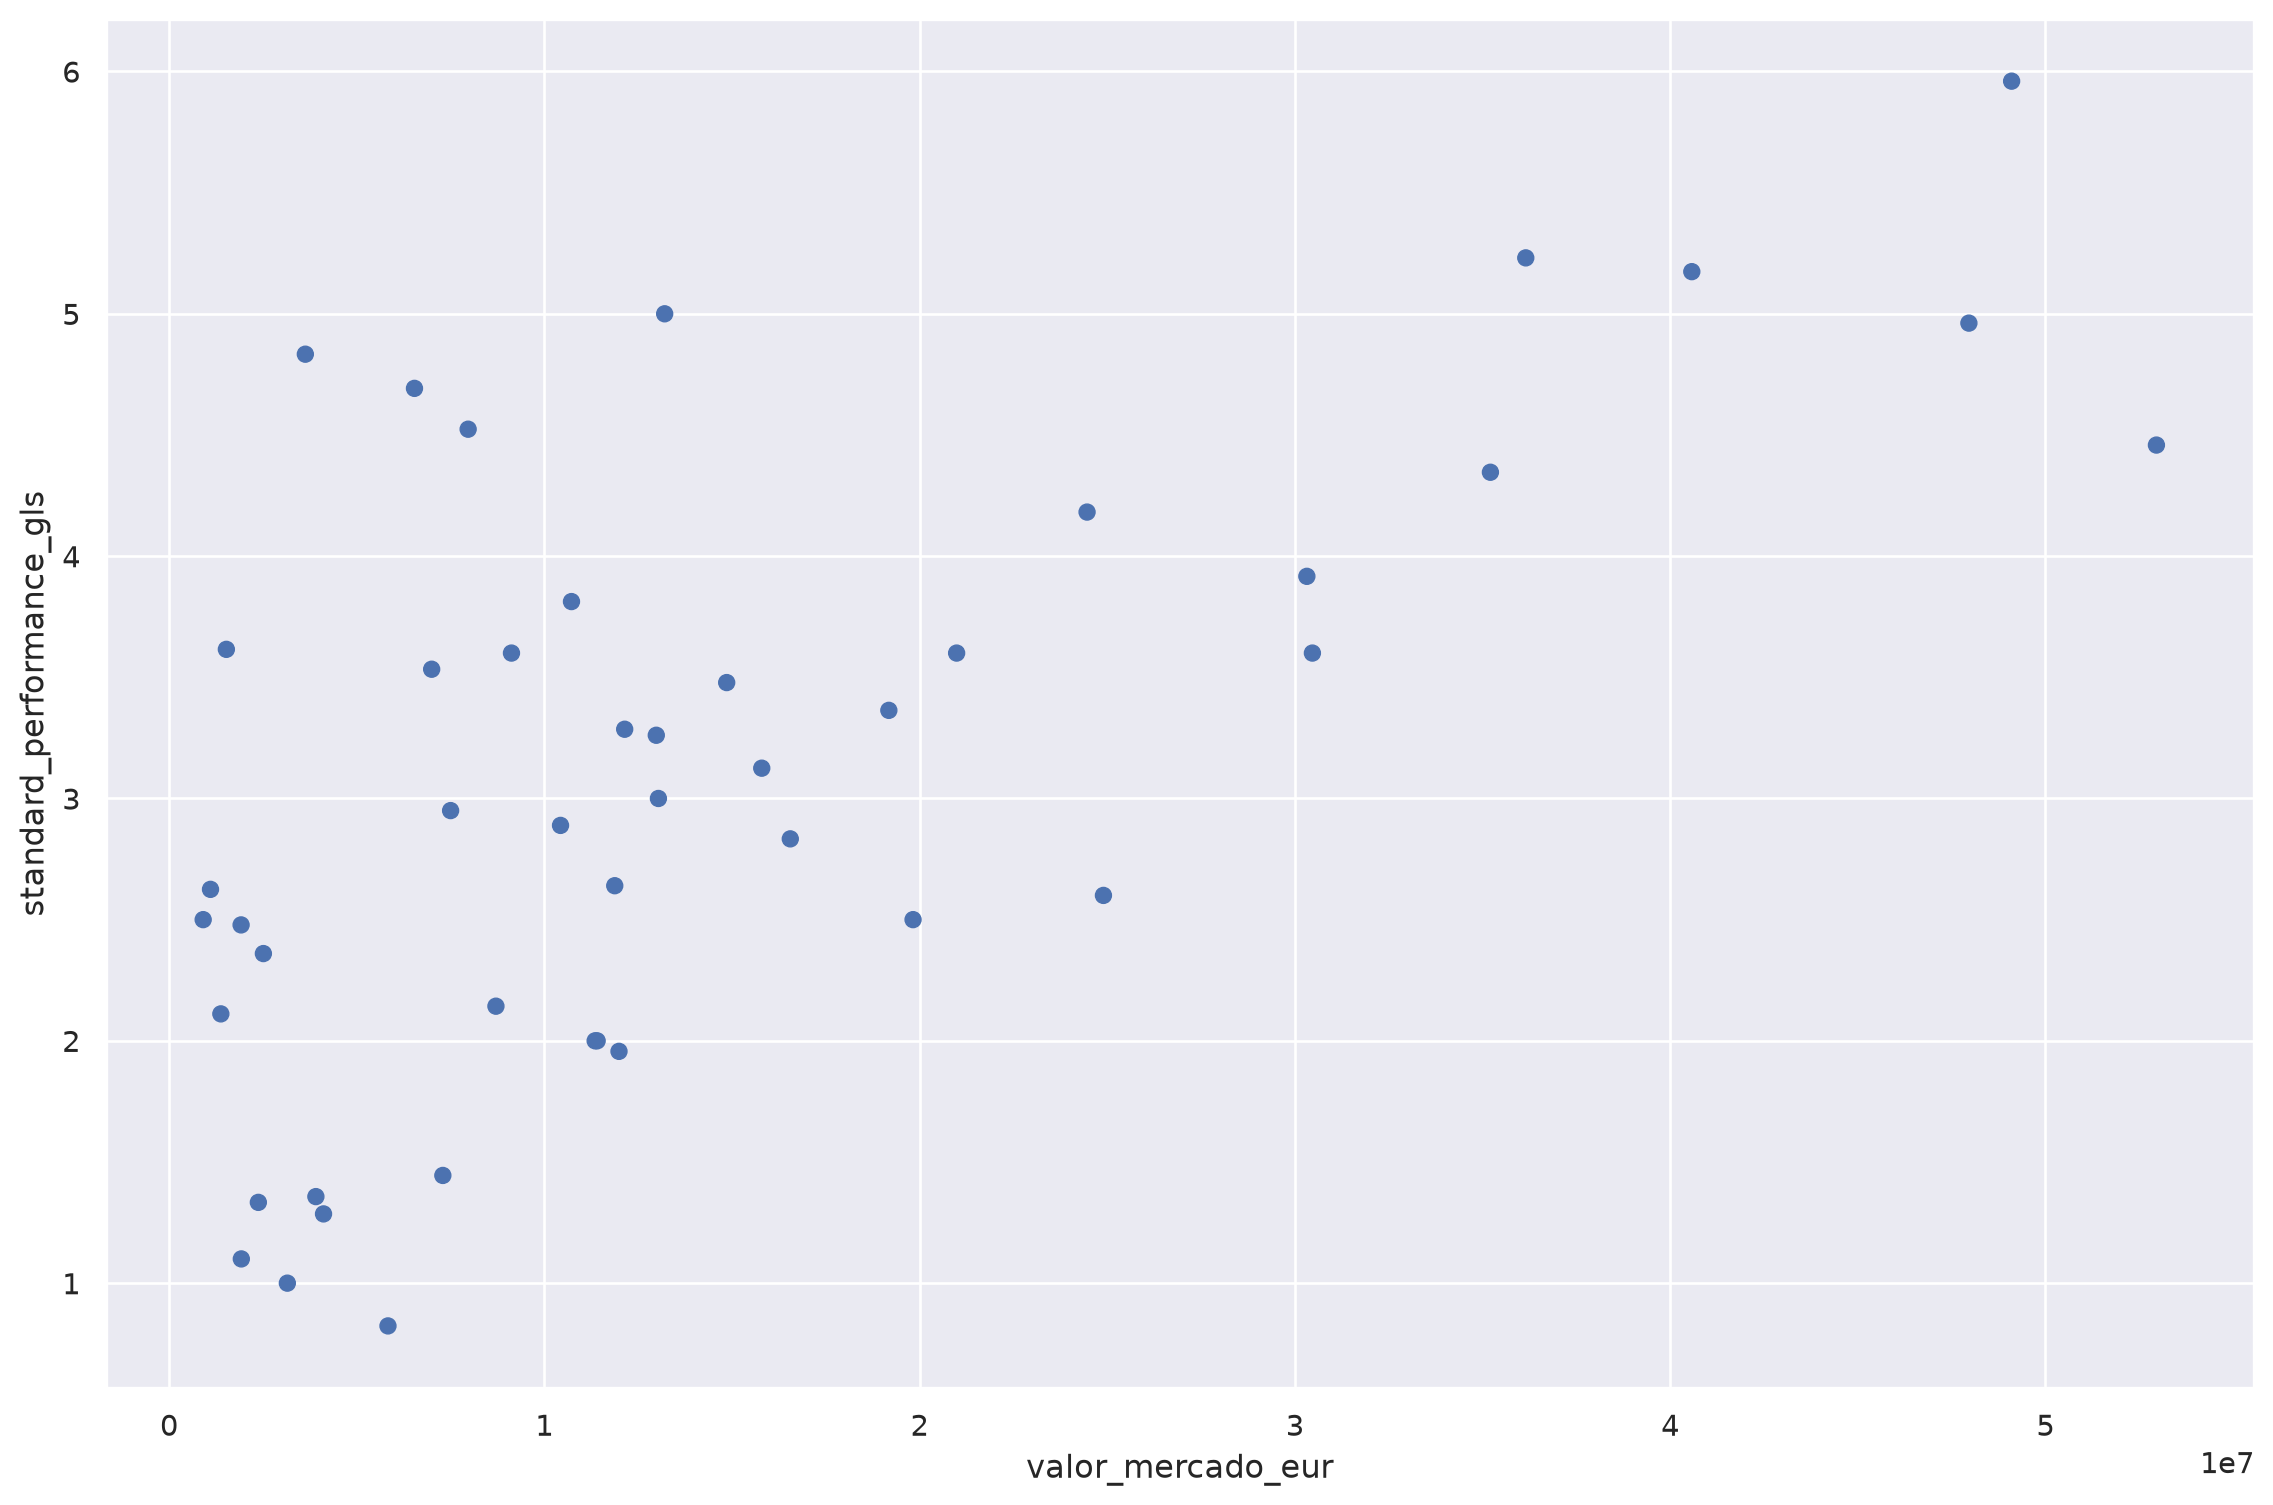

In [1148]:
# Graficamos
(
    so.Plot(data = df_selecciones, x = "valor_mercado_eur", y = "standard_performance_gls")
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Hay una clara relación lineal entre el promedio de goles de los jugadores de las selecciones, en sus respectivos clubes, en función del promedio del valor de los jugadores de las secciones en el mercado europeo. Pintemos las selecciones europeas para ver si esto tiene efecto sobre la distribución.

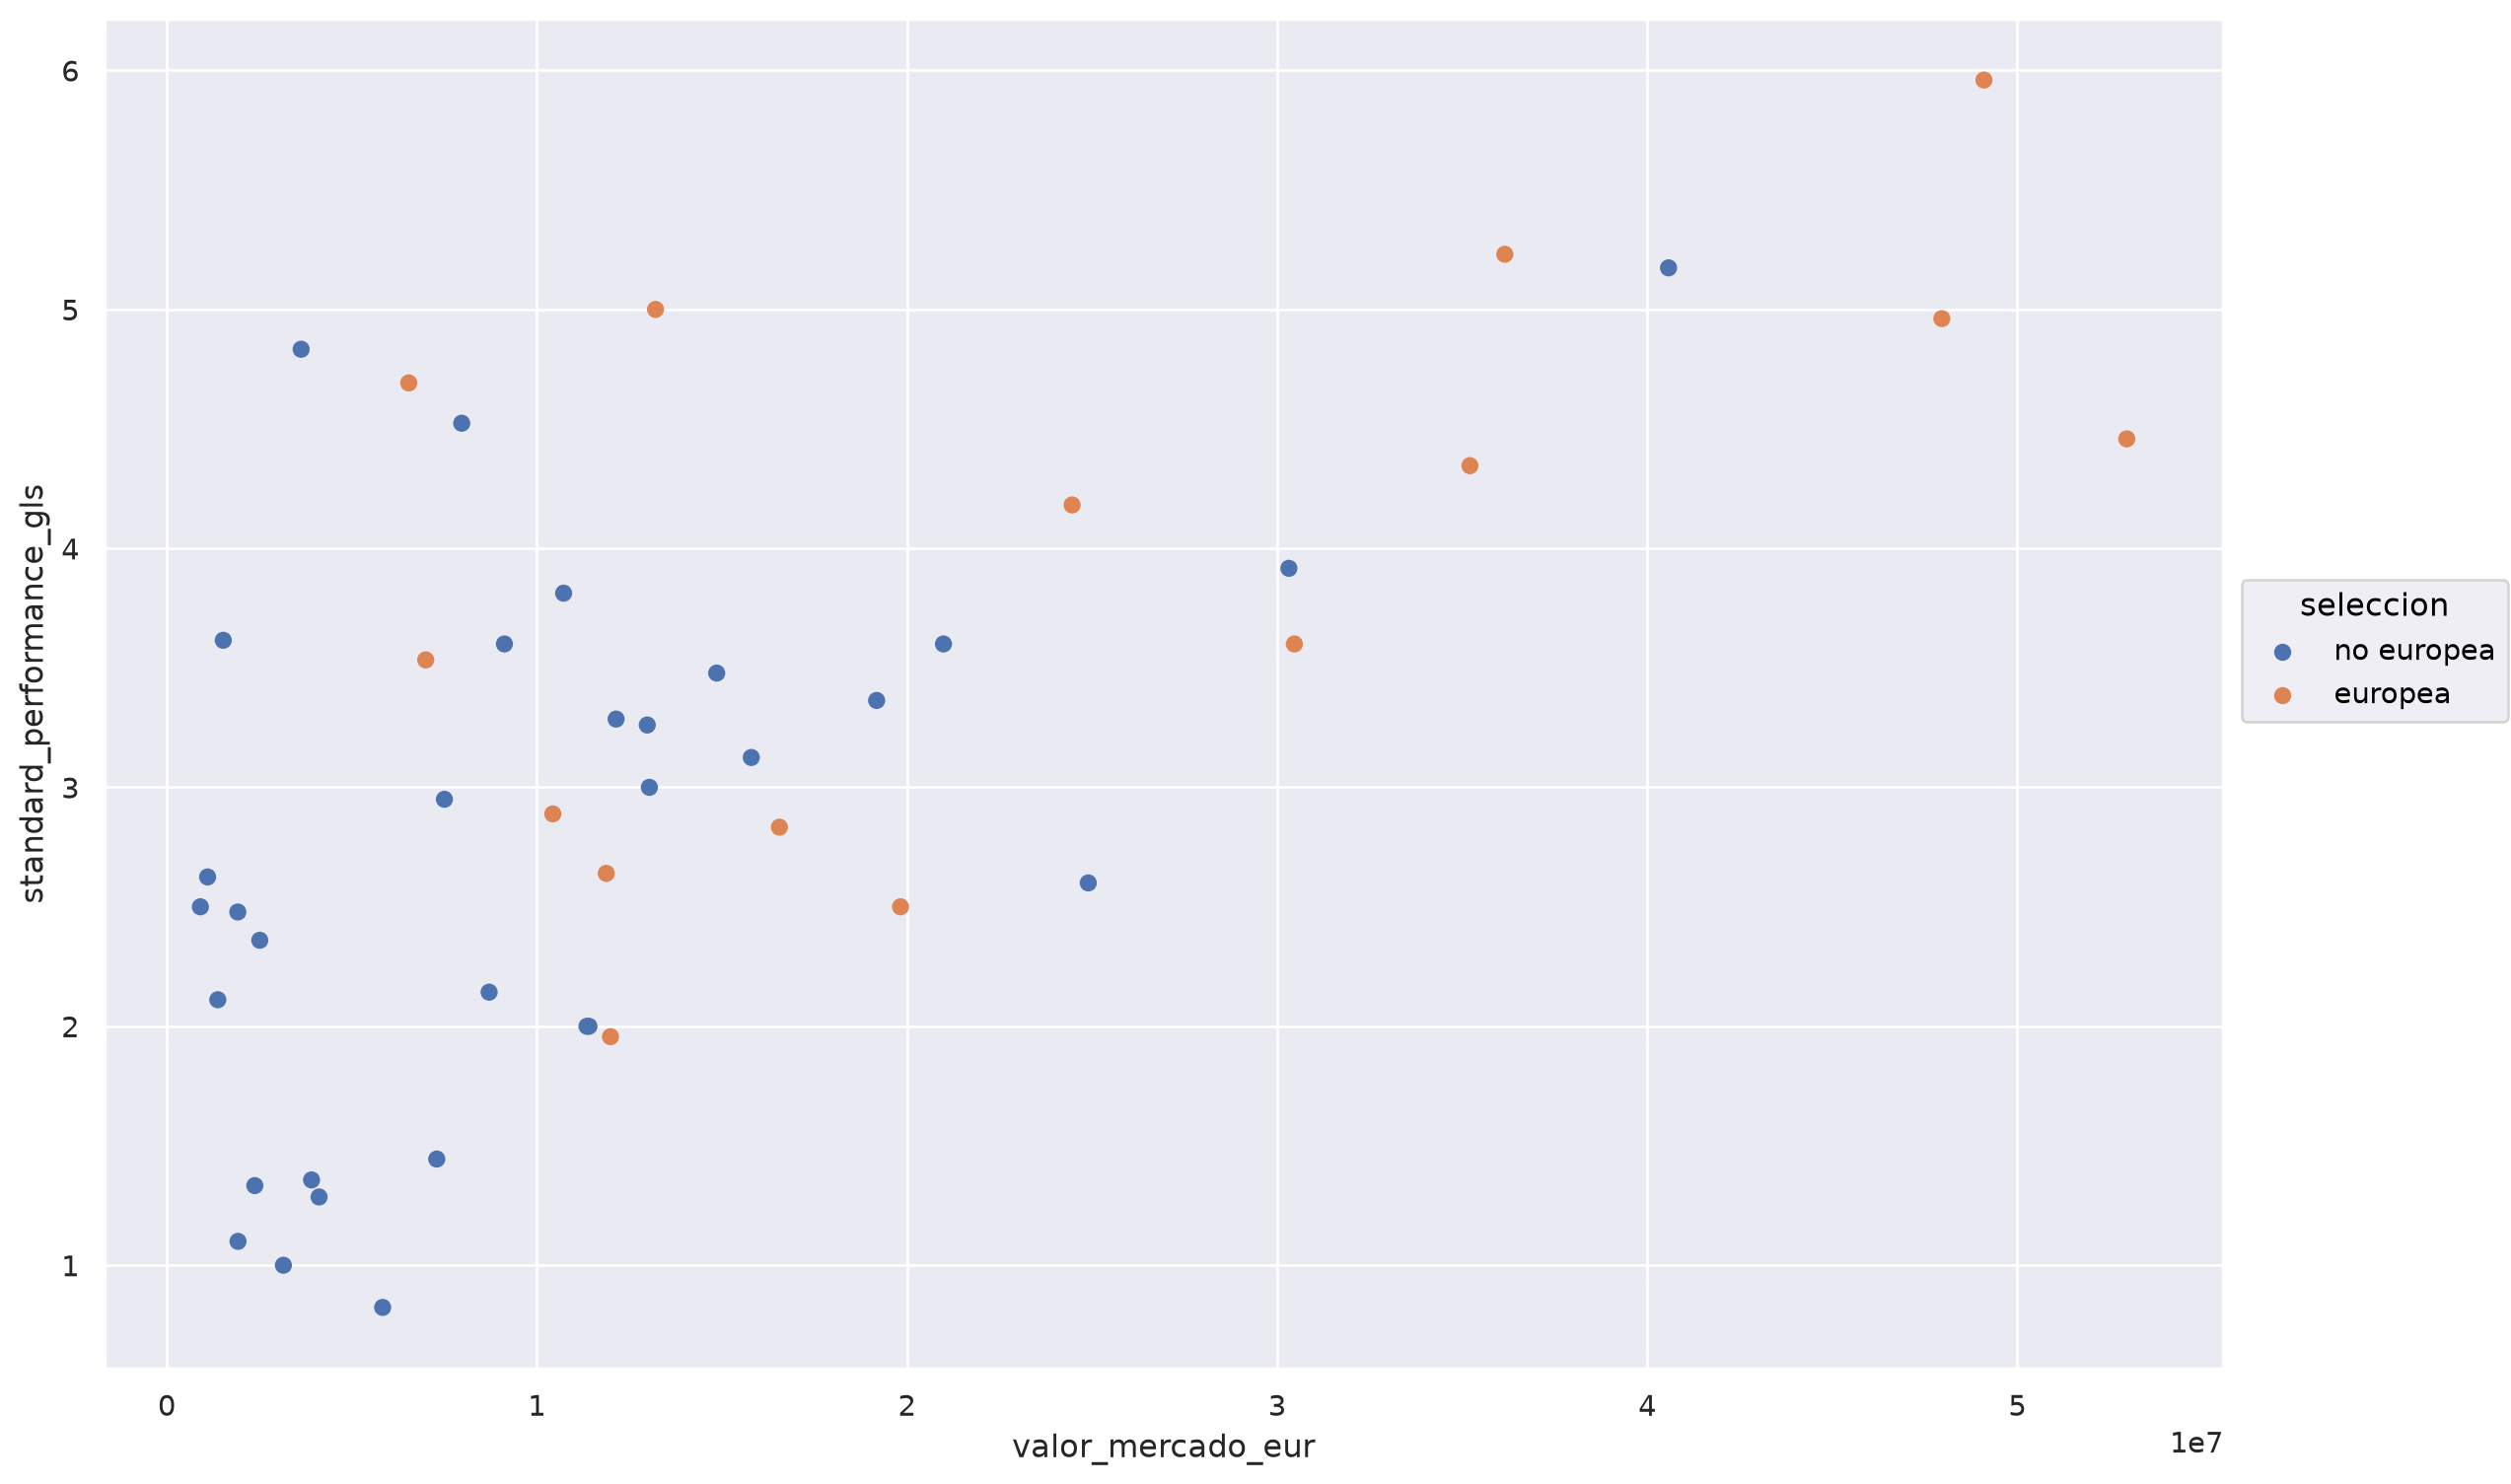

In [1149]:
selecciones_europeas = ["Austria",
    "Belgium",
    "Bosnia and Herzegovina",
    "Croatia",
    "Czech Republic",
    "England",
    "France",
    "Germany",
    "Netherlands",
    "Norway",
    "Portugal",
    "Scotland",
    "Spain",
    "Sweden",
    "Switzerland"
]

colores = df_selecciones.seleccion.isin(selecciones_europeas).map({True: "europea", False: "no europea"})

(
    so.Plot(data = df_selecciones, x = "valor_mercado_eur", y = "standard_performance_gls", color=colores)
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Claro está que las selecciones europeas tienen mayor promedio de valor en el mercado europeo, pero siguiendo la relación lineal esto genera que sus jugadores sean más goleadores en sus clubes

Ahora me interesa jugar con la edad y, basándome en la pregunta de la consigna, quiero ver si hay relación entre el tipo de juego de la selección (defensivo/ofensivo/neutro) según el promedio de edad de sus jugadores.

Primero, para arrancar, voy a tomar como ofensiva a una selección con más tarjetas, faltas, intercepciones y penales en contra. Por el contrario, las que tengan menos de estas variables serán neutras/defensivas.
(probar de agregar cantidad de tiros y de dividir por los minutos considerados para esa variable)

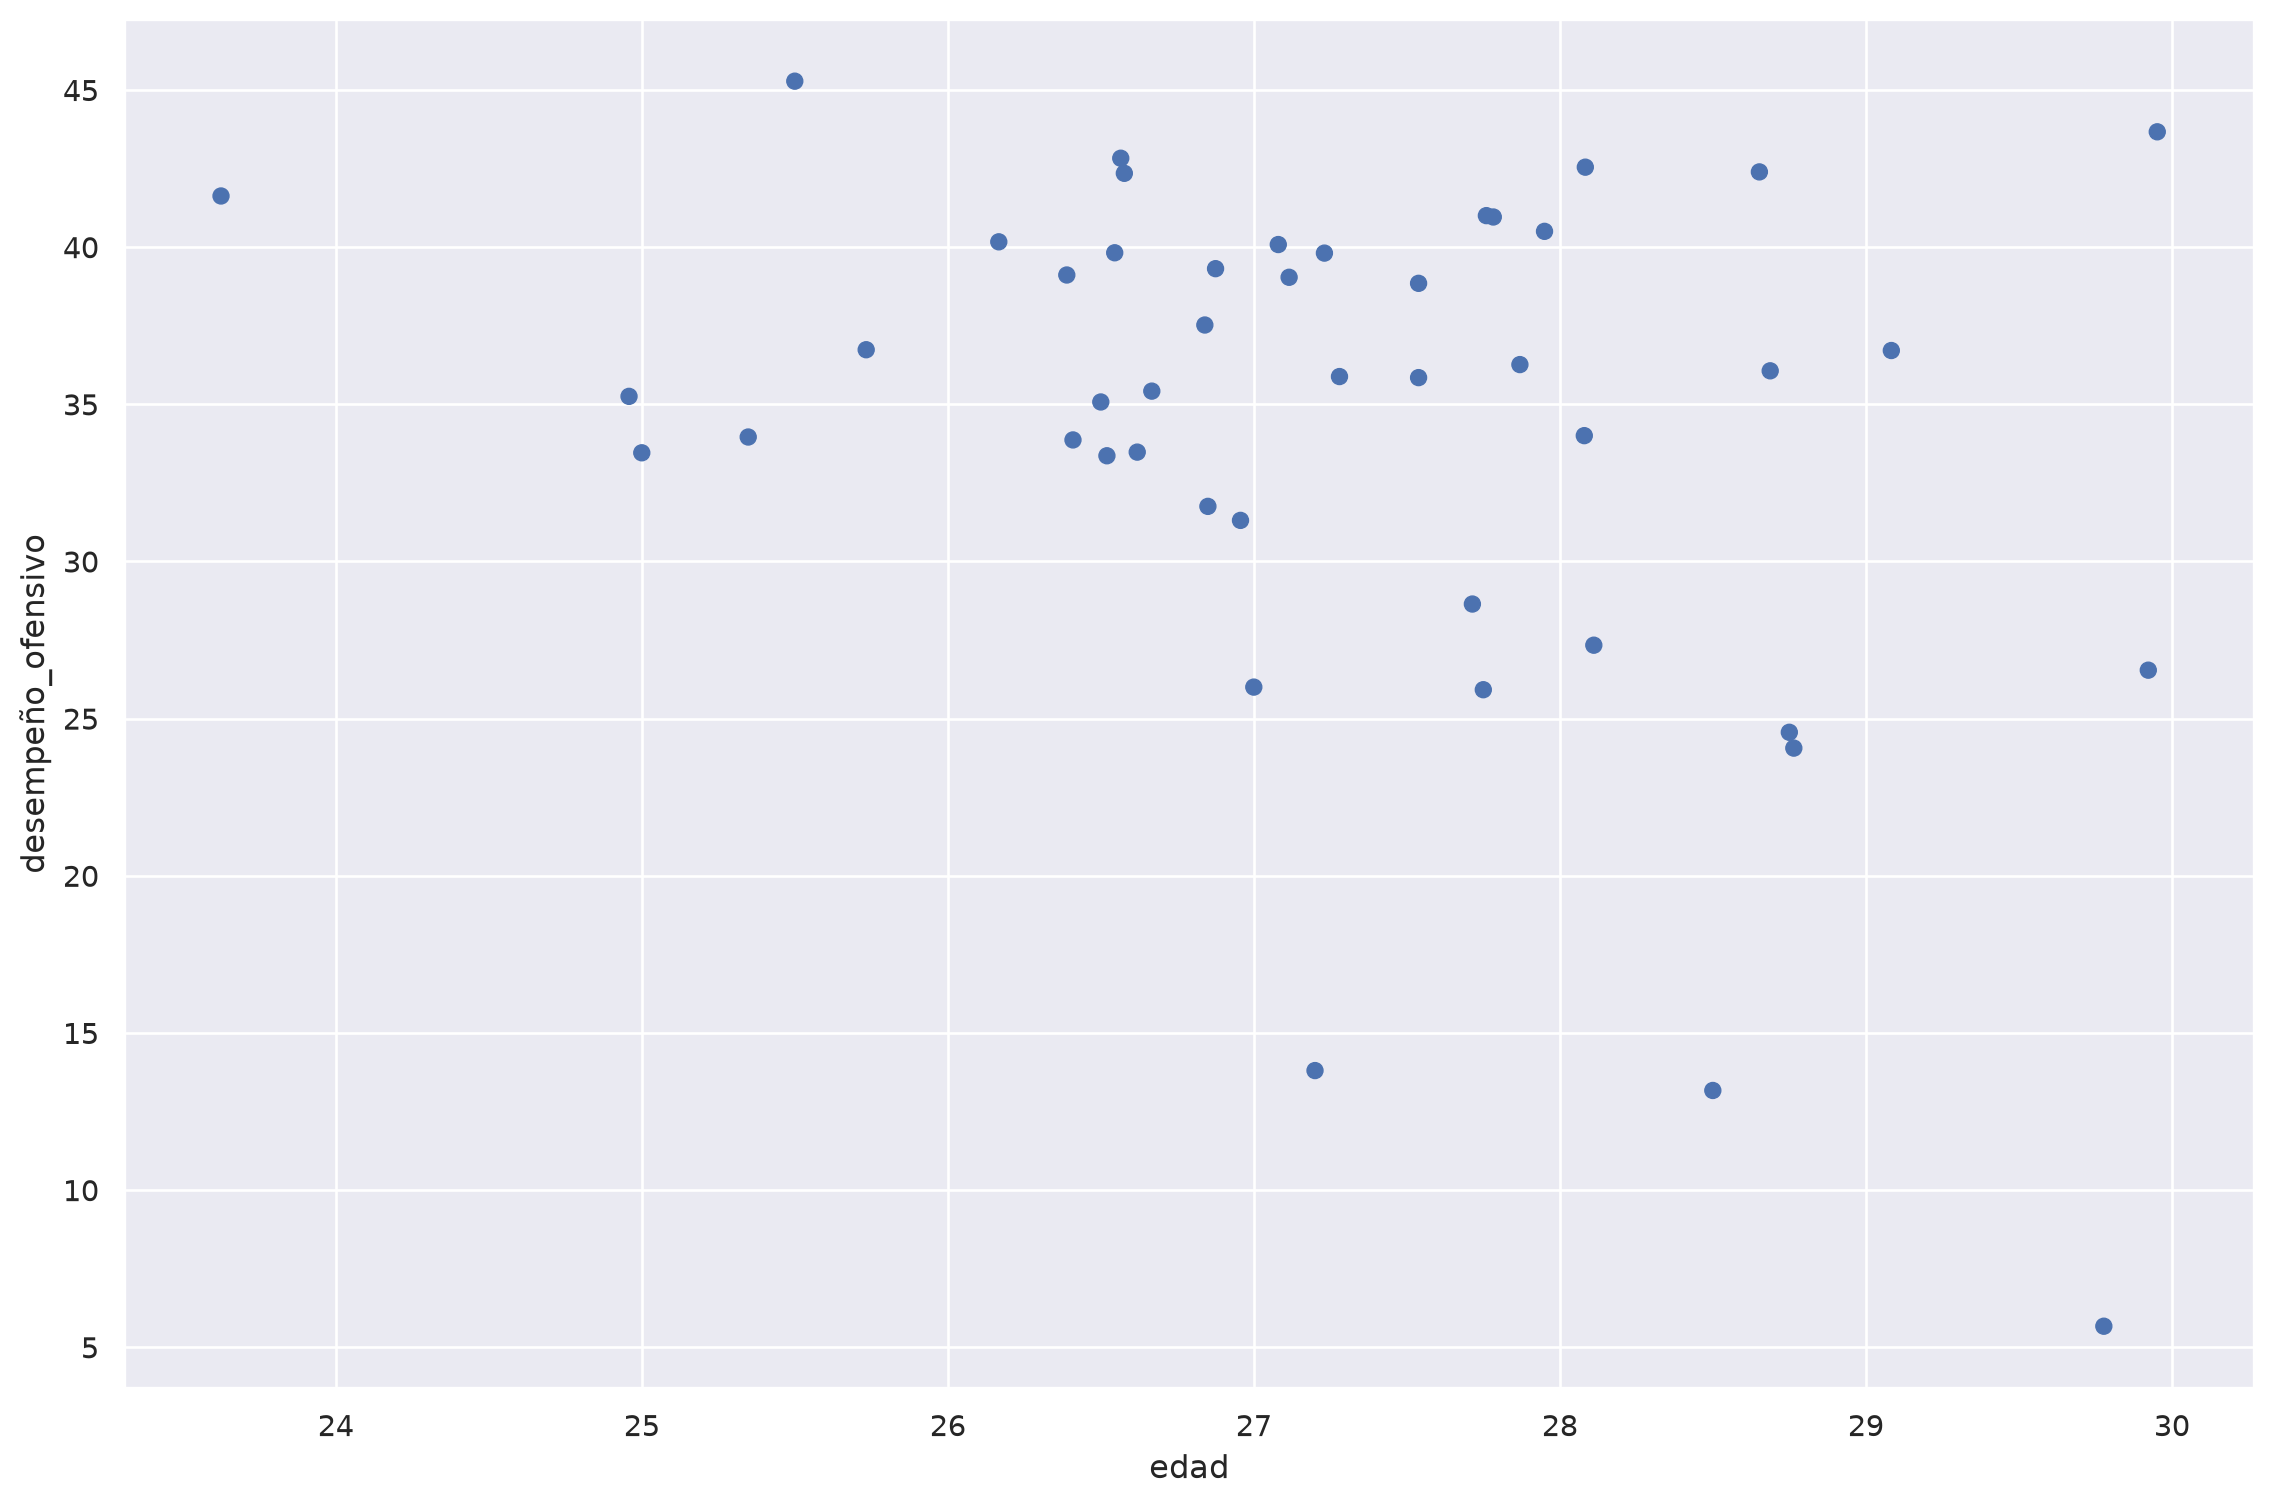

In [1150]:
variables_ofensivas = ["misc_performance_crdy", "misc_performance_crdr", "misc_performance_2crdy", "misc_performance_fls", "misc_performance_int"]
suma_ofensiva = df_selecciones[variables_ofensivas].sum(axis=1)
suma_ofensiva.name = "desempeño_ofensivo"

(
    so.Plot(data = df_selecciones, x = "edad", y = suma_ofensiva)
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

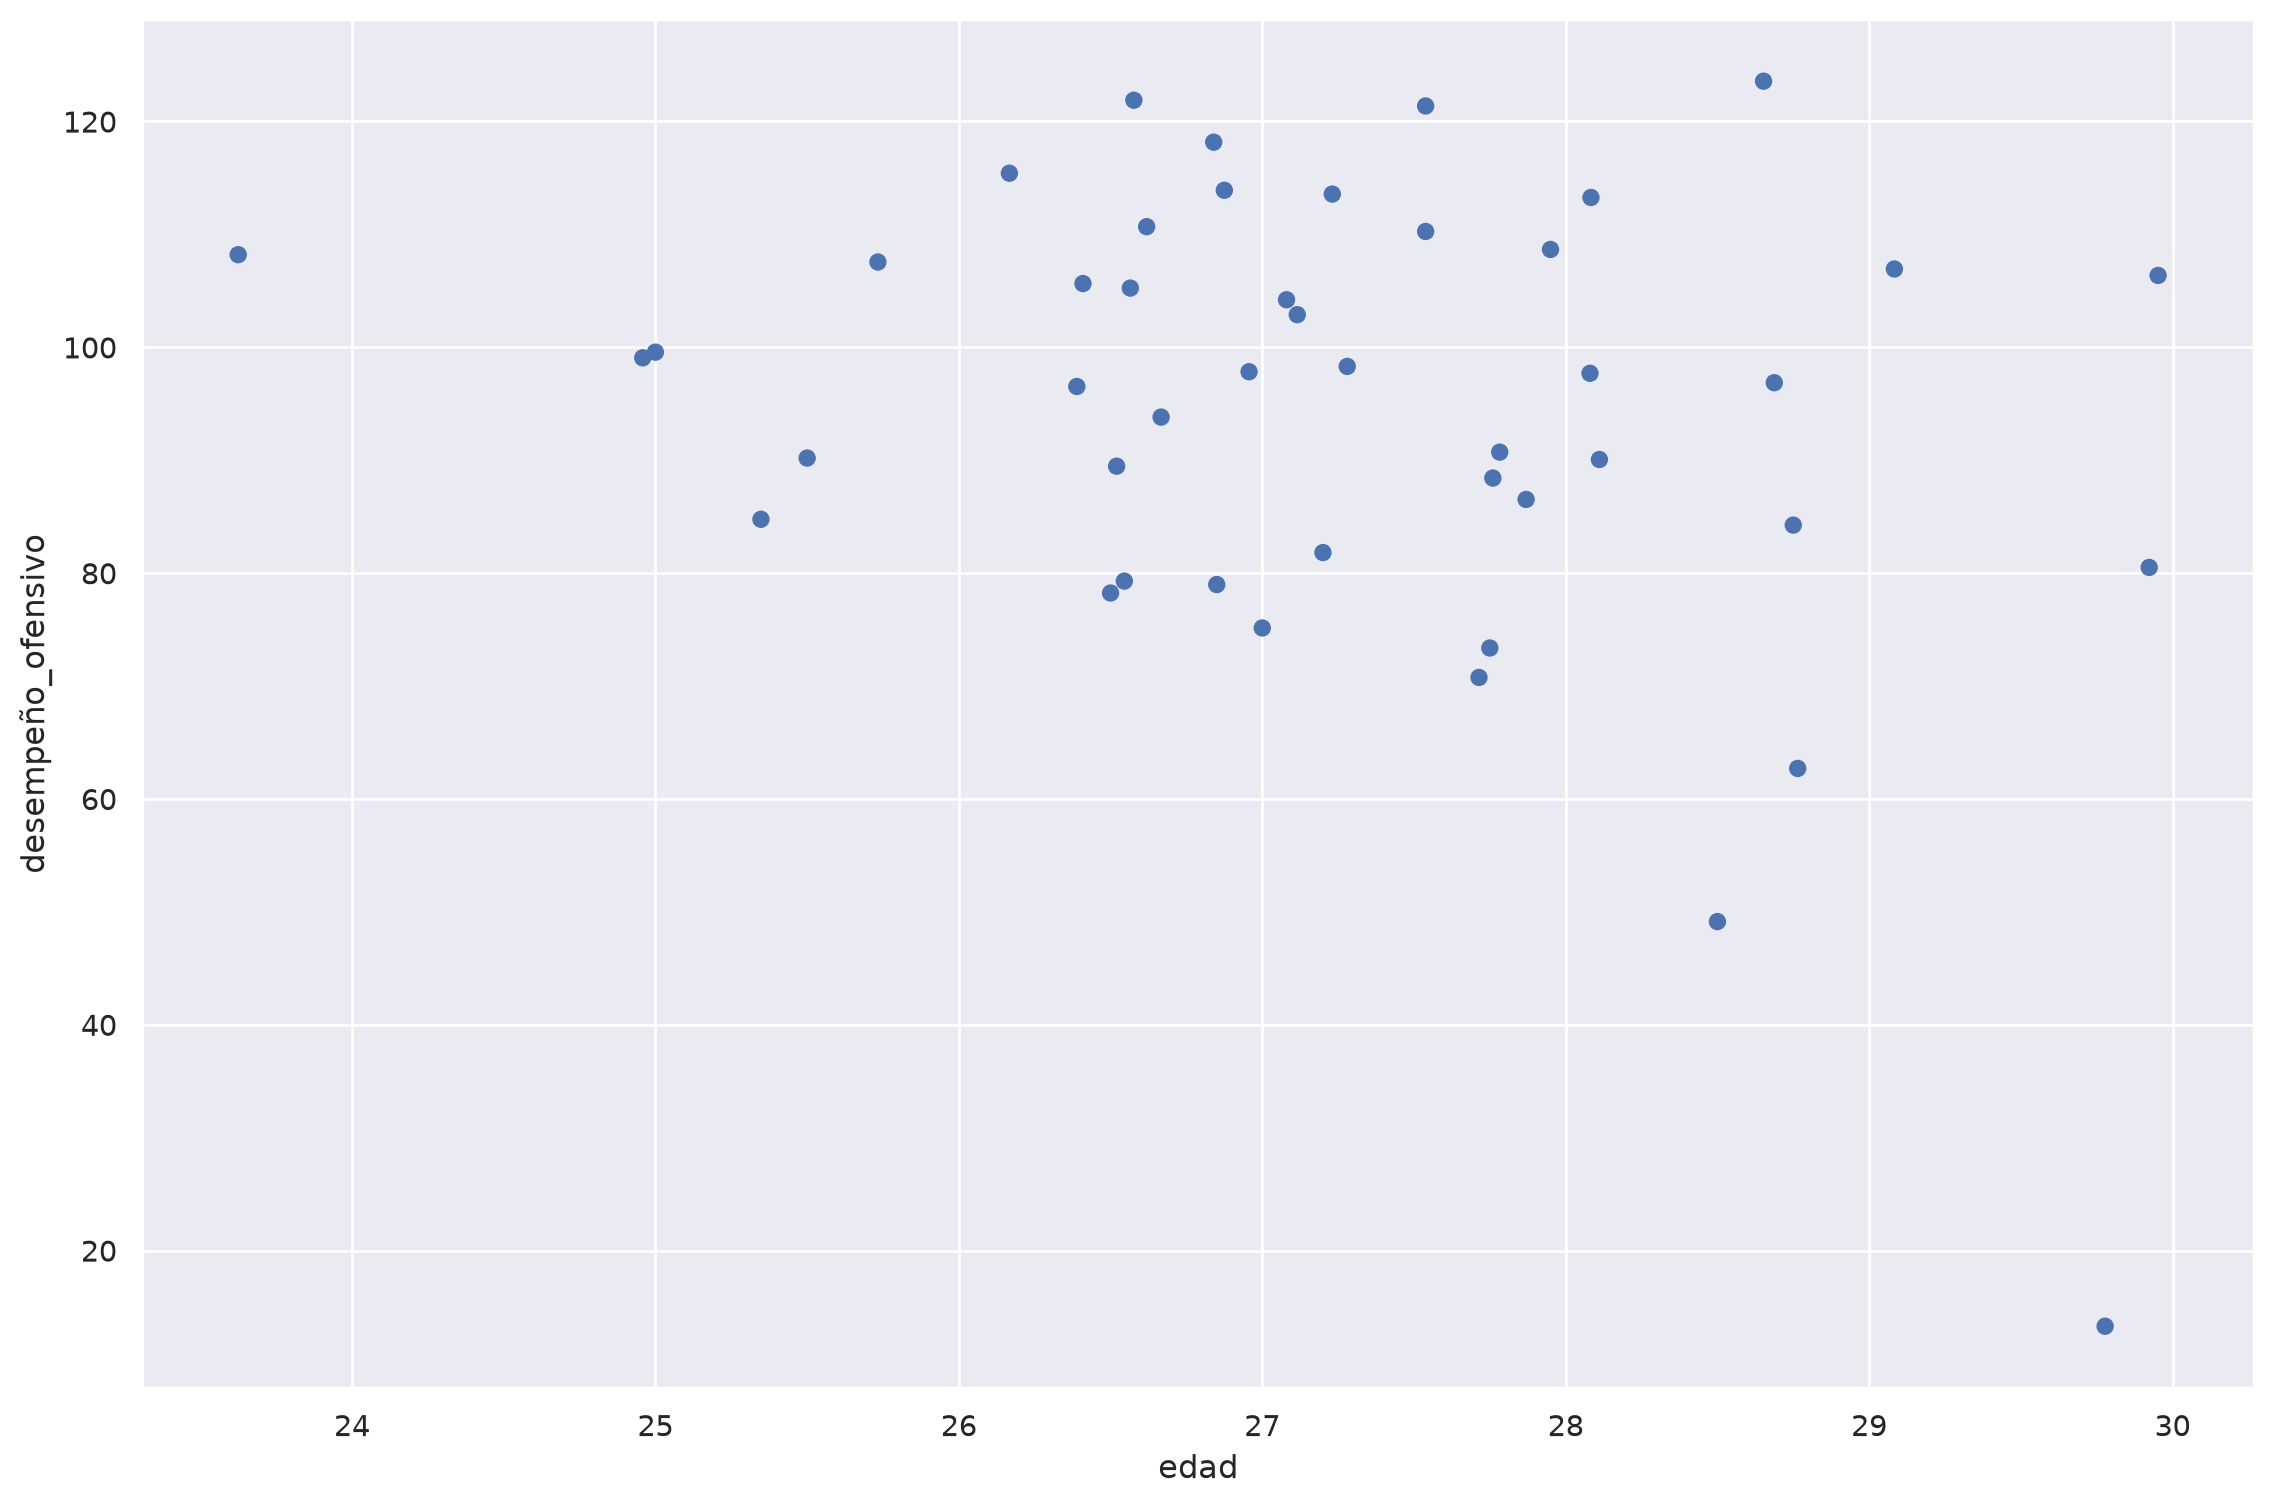

In [1151]:
variables_ofensivas = ["misc_performance_crdy", "misc_performance_crdr", "misc_performance_2crdy", "misc_performance_fls", "misc_performance_int"]
variables_tiros = ["shooting_standard_sh", "shooting_standard_sot", "shooting_standard_sotpct"]
suma_ofensiva = df_selecciones[variables_ofensivas].sum(axis=1) + df_selecciones[variables_tiros].sum(axis=1)
suma_ofensiva.name = "desempeño_ofensivo"

(
    so.Plot(data = df_selecciones, x = "edad", y = suma_ofensiva)
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

In [1152]:
df_selecciones[variables_ofensivas].sum(axis=1).name = "desempeño_ofensivo"

# PCA y Clustering

In [1153]:
import seaborn.objects as so
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 1.

In [1154]:
df_selecciones_numerica = df_selecciones.drop(columns=["seleccion"])

In [1155]:
df_selecciones_numerica_escalada = StandardScaler().set_output(transform="pandas").fit_transform(df_selecciones_numerica)

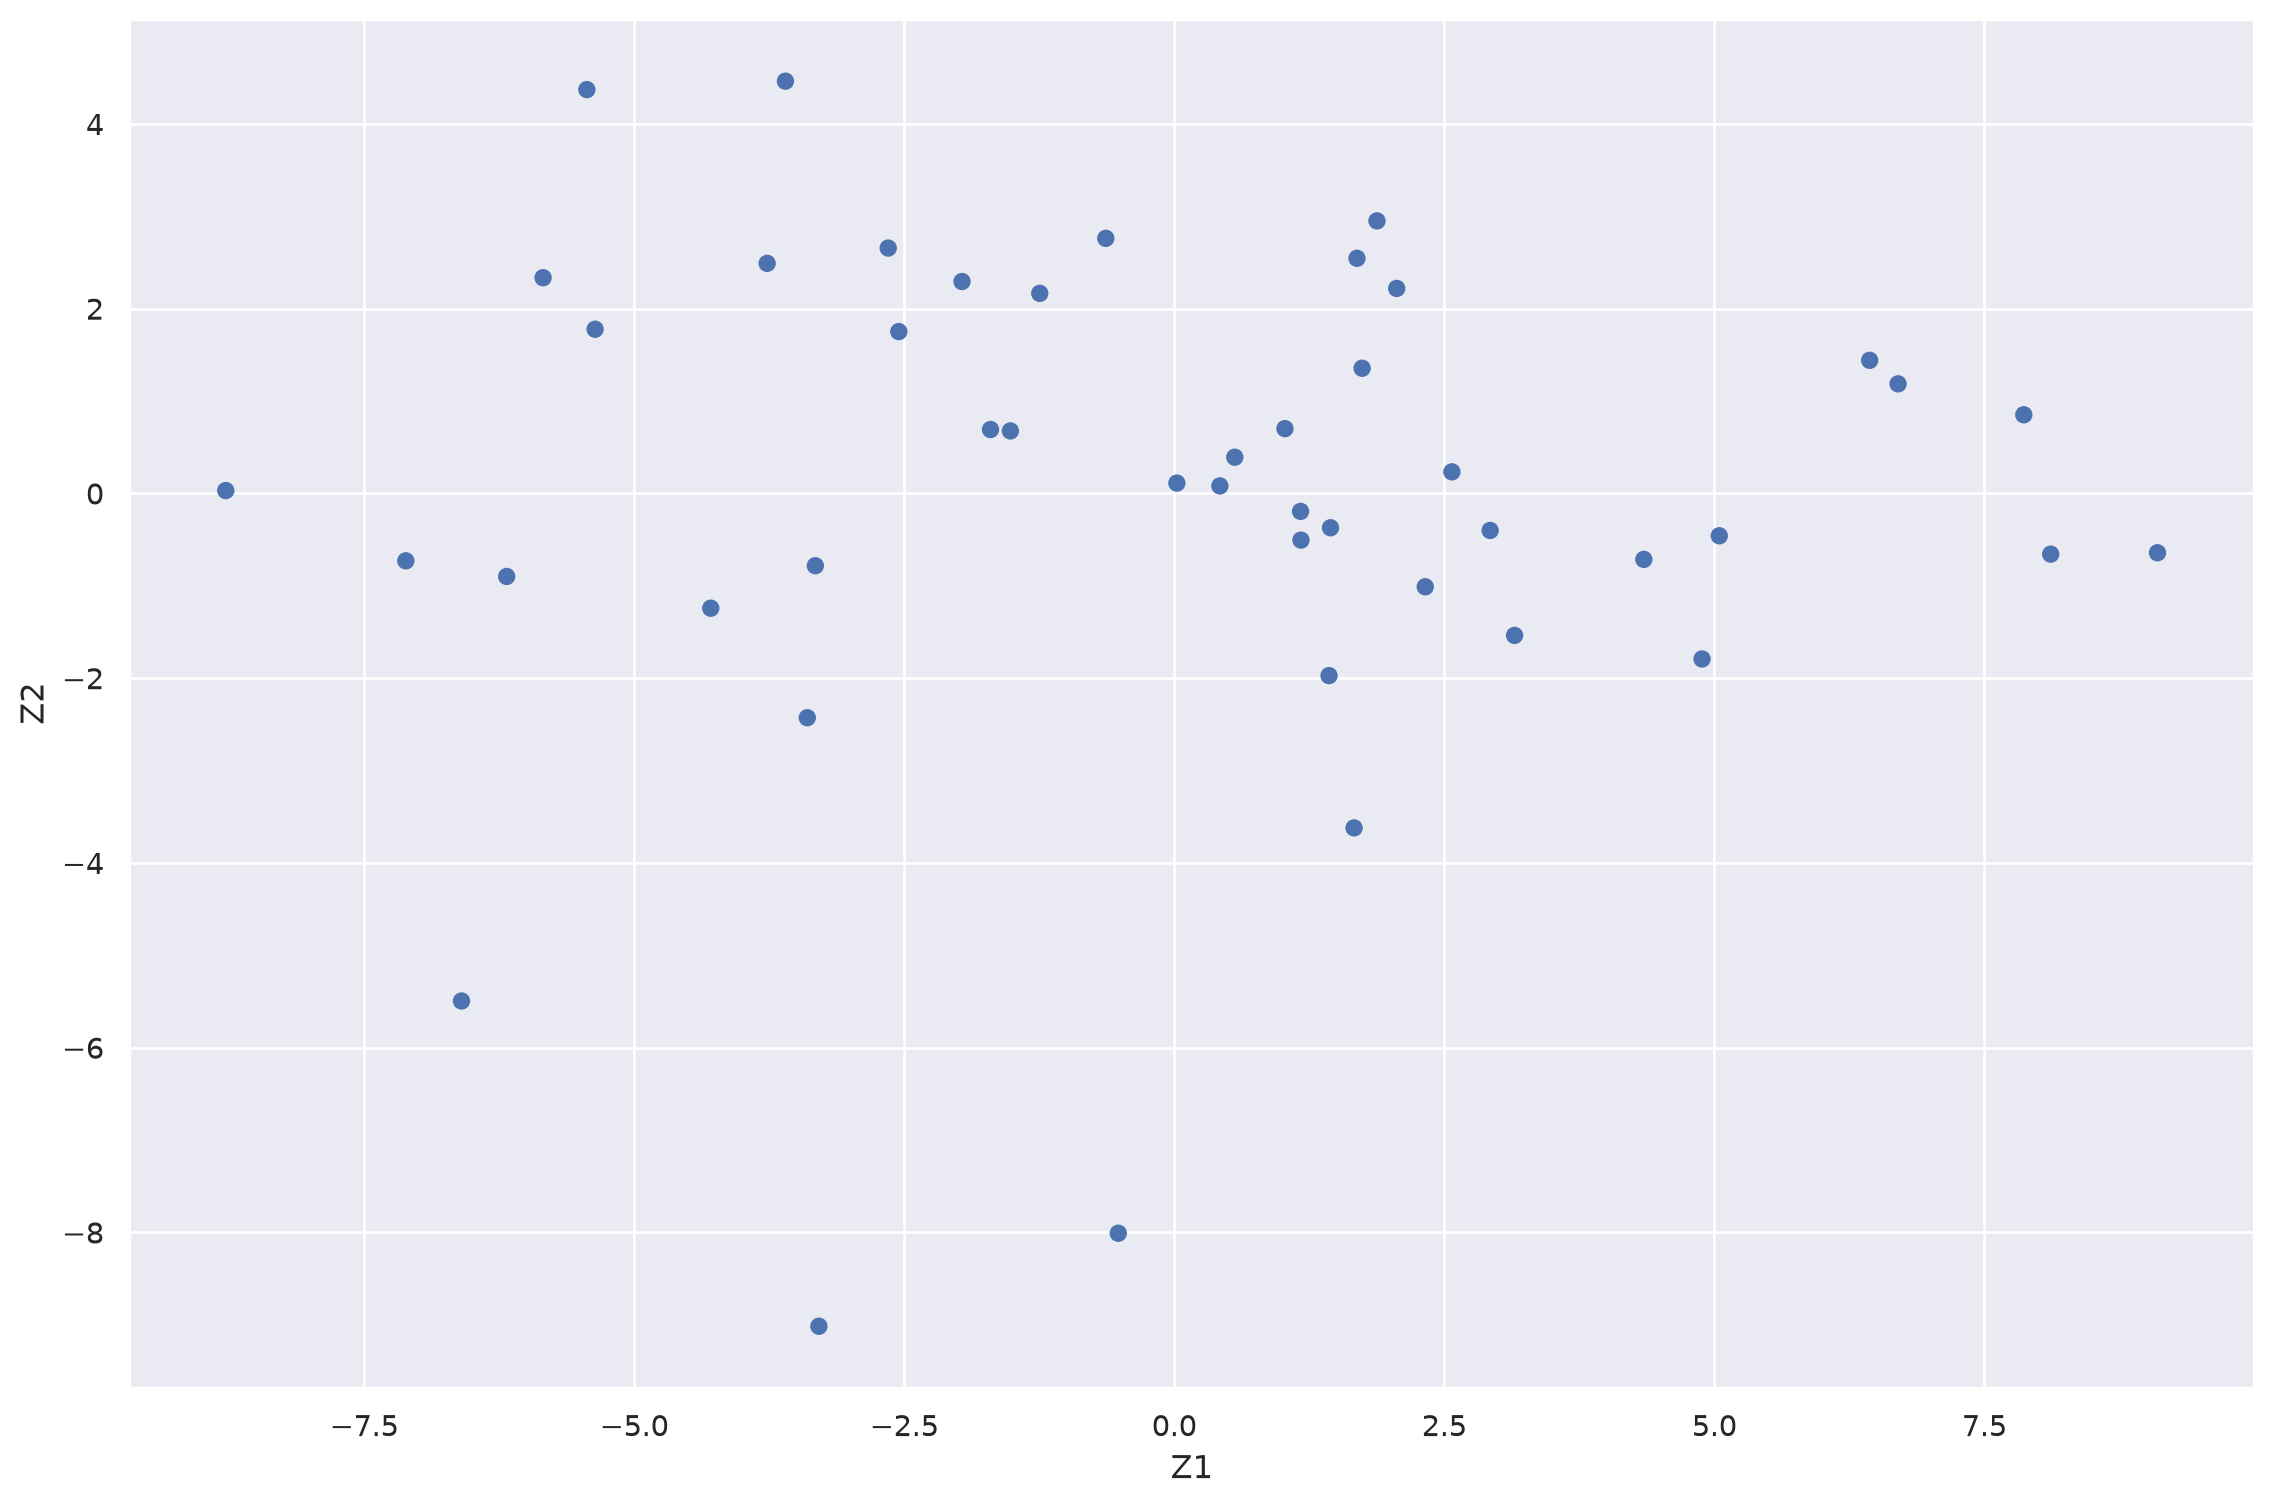

In [1156]:
n = 2
pca = PCA(n_components=n)

X = df_selecciones_numerica_escalada
Z = pd.DataFrame(pca.fit_transform(X))

Z.columns = ["Z" + str(i) for i in range(1,n+1)]  # Renombramos las columnas

# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2")
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Se puede ver que hay aproximadamente dos grupos, superior izquierda y superior derecha, con varios outliers en el inferior

## 2.

In [1157]:
z1 = pd.Series(pca.components_[0])
direcciones_z1 = pd.DataFrame({
	"valores_negativos": z1.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z1.sort_values().head(10).index],
	"valores_positivos": z1.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z1.sort_values(ascending=False).head(10).index]
})
direcciones_z1

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.014015,misc_performance_2crdy,0.224063,standard_performance_gpa
1,-0.009418,edad,0.218128,shooting_standard_sot
2,0.001081,misc_performance_crdr,0.214220,shooting_standard_sh
3,0.001081,standard_performance_crdr,0.212979,standard_performance_gls
4,0.016361,misc_performance_og,0.212842,shooting_standard_gls
5,0.031907,goles_seleccion,0.210781,standard_performance_g-pk
6,0.036041,caps,0.191854,standard_performance_ast
7,0.036422,shooting_standard_g_per_sh,0.190188,standard_playing_time_starts
8,0.083605,misc_performance_int,0.188728,standard_playing_time_90s
9,0.101740,misc_performance_crdy,0.188682,standard_playing_time_min


z1 le da principalmente peso a la cantidad de goles y asistencias, junto con la cantidad de tiempo/partidos jugados

In [1158]:
z2 = pd.Series(pca.components_[1])
direcciones_z2 = pd.DataFrame({
	"valores_negativos": z2.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z2.sort_values().head(10).index],
	"valores_positivos": z2.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z2.sort_values(ascending=False).head(10).index]
})
direcciones_z2

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.284674,goles_seleccion,0.292684,misc_performance_int
1,-0.245326,caps,0.265067,misc_performance_tklw
2,-0.195709,standard_per_90_minutes_gls,0.262395,misc_performance_fls
3,-0.193217,standard_per_90_minutes_gpa,0.219218,standard_performance_crdy
4,-0.192035,standard_per_90_minutes_g-pk,0.217716,misc_performance_crdy
5,-0.191646,standard_per_90_minutes_gpa-pk,0.189744,misc_performance_fld
6,-0.147578,edad,0.170014,standard_playing_time_mp
7,-0.124537,standard_performance_pk,0.147201,standard_playing_time_min
8,-0.124537,shooting_standard_pk,0.147163,standard_playing_time_90s
9,-0.124453,standard_per_90_minutes_ast,0.146978,misc_performance_2crdy


z2 le da principalmente peso a otras características como tarjetas o intercepciones, y también a la cantidad de tiempo y partidos jugados

DAR INTERPRETACION!!!!!!!!!!!!!!!!!!

## 3.

In [1159]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

In [1160]:
# n = 5
# neighbors = NearestNeighbors(n_neighbors=n)  # Esta función nos devuelve los más cercanos incluyendo a si mismo.
# neighbors_fit = neighbors.fit(df_selecciones_numerica_escalada)

# # Ordenamos de menor a mayor las distancias y graficamos
# distances, indices = neighbors_fit.kneighbors(df_selecciones_numerica_escalada)
# distances = distances[:,n-1] # Tomamos la distancia al vecino más lejano (el n-ésimo vecino)
# distances = np.sort(distances, axis=0)

# so.Plot(x = np.arange(len(distances)), y = distances).add(so.Line())

In [1161]:
# clustering = DBSCAN(eps= 5.5, min_samples=n)
# etiqueta = clustering.fit_predict(df_selecciones_numerica_escalada)

In [1162]:
kmeans = KMeans(4)
# Asignamos cada observación a un cluster
cluster = kmeans.fit_predict(df_selecciones_numerica_escalada)

## 4.

In [1163]:
# # Graficamos
# (
#     so.Plot(data = Z, x = "Z1", y = "Z2", color = etiqueta.astype(str))
#     .add(so.Dot())
#     .add(so.Text())
#     .layout(size=(12,8))
# )

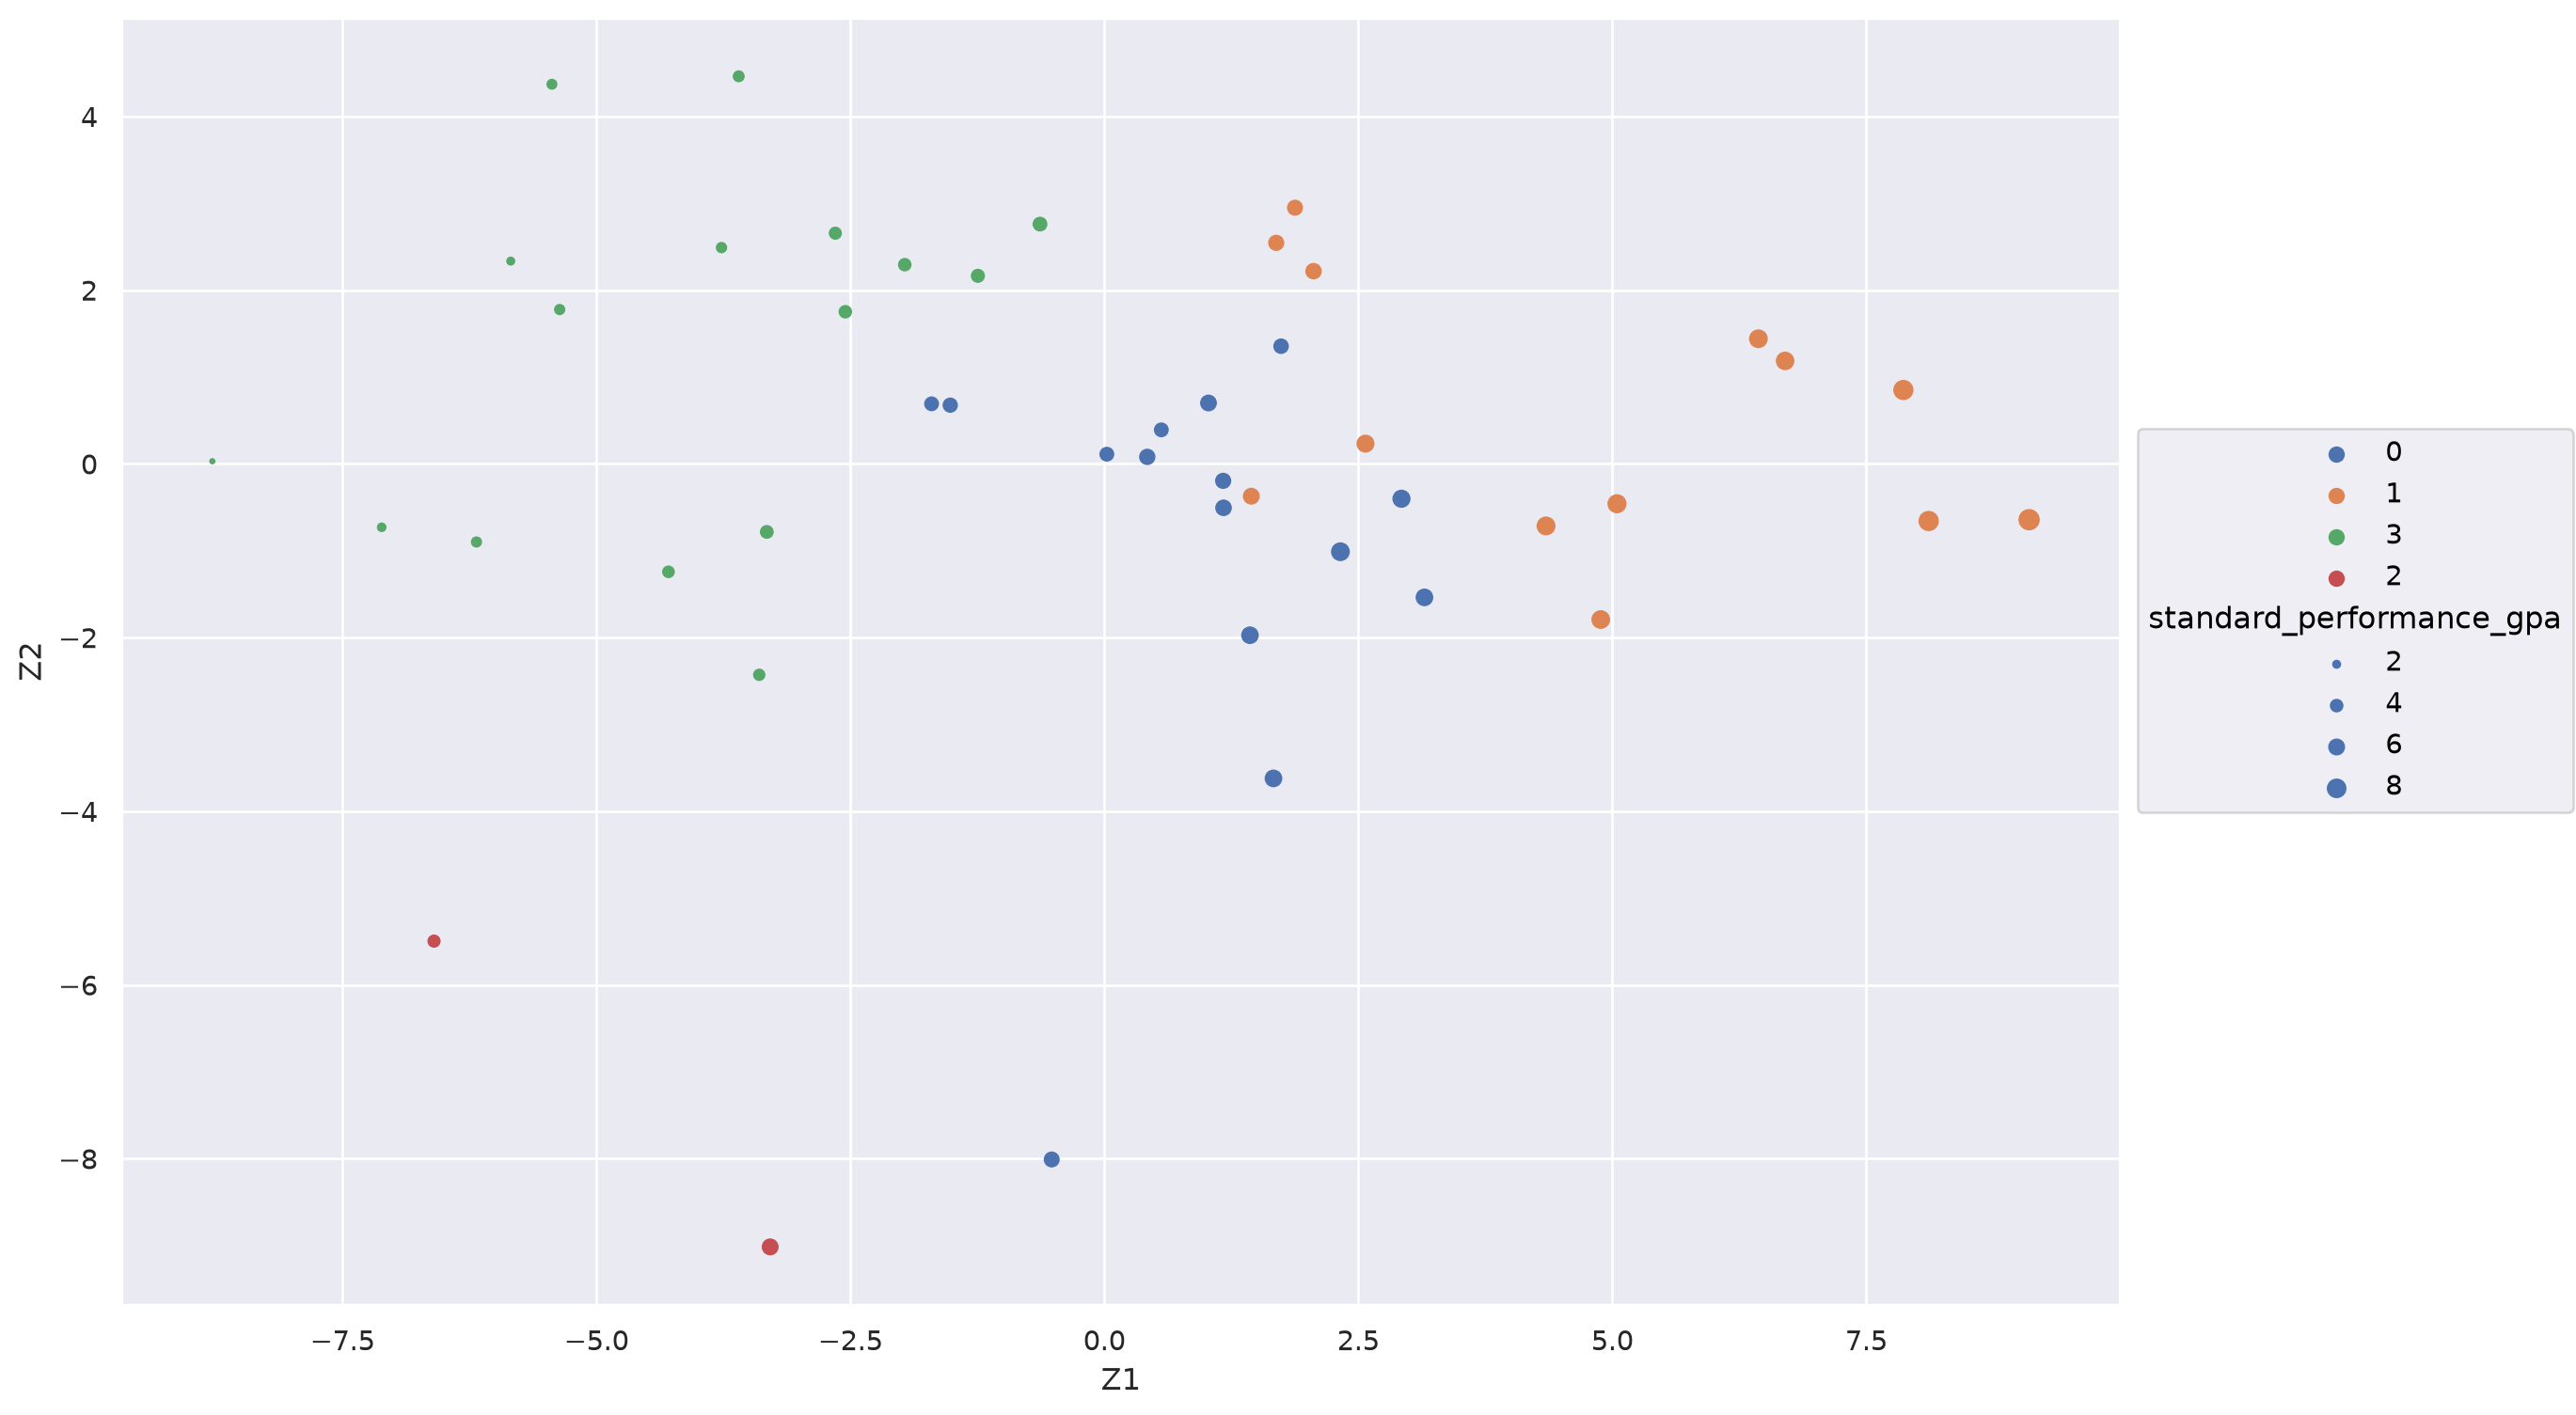

In [1164]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", color = cluster.astype(str), pointsize=df_selecciones["standard_performance_gpa"])
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Una forma de verlo es que todas las selecciones tienen cantidad parecida de faltas/tarjetas (porque estan a misma altura en z2) pero aquellas que jugaron menos tiempo (negativo en z1) tienen peor rendimiento, pues generaron las mismas tarjetas y menos goles en menos tiempo de juego. Por ello los clusters se dividen de cierta forma segun el rendimiento "(tarjetas+goles)/(tiempo_jugado+partidos_jugados)".

Aunque parece que hay cierta coincidencia entre el clustering con los puntos creo que no es correcto, pues mete en un mismo cluster selecciones que varian mucho en z2 y entonces no comparten mismas características

In [1165]:
X_star = df_selecciones_numerica_escalada

In [1166]:
# Calculamos la matriz de covarianza:
# cov = (X - Xraya)^T * (X - Xraya) / N = (B^T * B) / N
X_star_t = np.transpose(X_star)
N = len(X_star)
Sigma = (X_star_t @ X_star) / N
# display(Sigma)

In [1167]:
gamma, U = np.linalg.eigh(Sigma)  # Usamos eigh porque A es simétrica. Podemos usar eig también
display(gamma)
display(U)

array([-8.95507169e-16, -2.44470222e-16, -7.20240151e-17, -6.24850085e-17,
        3.11662874e-16,  3.65284722e-16,  1.14252487e-15,  7.05449695e-07,
        5.35404120e-06,  7.61017459e-05,  3.02394067e-04,  3.80849854e-04,
        8.26239359e-04,  2.23382212e-03,  2.86228089e-03,  9.02828201e-03,
        1.86780560e-02,  2.27908549e-02,  2.65063561e-02,  3.85710502e-02,
        4.43786564e-02,  6.71202527e-02,  7.95252384e-02,  1.05423100e-01,
        1.30888583e-01,  1.66466745e-01,  2.13980421e-01,  2.42867188e-01,
        2.63851309e-01,  3.51610854e-01,  3.86514043e-01,  5.11100162e-01,
        5.97017137e-01,  7.02329591e-01,  8.43324327e-01,  1.16306880e+00,
        1.37890498e+00,  1.54410675e+00,  1.89730672e+00,  3.04194000e+00,
        4.22729008e+00,  6.95873730e+00,  1.79599854e+01])

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.59222683e-01, -1.47577808e-01, -9.41795932e-03],
       [ 4.62614521e-14, -2.78982172e-15, -5.39723842e-15, ...,
        -1.54112232e-01, -2.45325808e-01,  3.60409062e-02],
       [-6.07213627e-14,  1.02265165e-14,  1.59795297e-14, ...,
         1.43785969e-02, -2.84674354e-01,  3.19066228e-02],
       ...,
       [-6.54380495e-14, -1.67538726e-14,  1.73085949e-14, ...,
         9.82093684e-02,  2.65067451e-01,  1.08338173e-01],
       [ 3.77057321e-14,  3.47664999e-14,  6.22476352e-15, ...,
        -1.43708279e-01,  2.93047660e-02,  1.63614132e-02],
       [ 7.32722094e-14,  3.93454691e-14, -2.08282255e-14, ...,
        -4.56743244e-03,  1.51894553e-02,  1.78599560e-01]],
      shape=(43, 43))

In [1168]:
# Los autovalores están ordenados de menor a mayor.
# Damos vueltas las columnas de la matriz de autovectores usando np.flip(-,1)
gamma = np.flip(gamma)
U = np.flip(U, 1)   # U tiene los autovectores de Sigma como columnas
print(U)

[[-9.41795932e-03 -1.47577808e-01 -2.59222683e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.60409062e-02 -2.45325808e-01 -1.54112232e-01 ... -5.39723842e-15
  -2.78982172e-15  4.62614521e-14]
 [ 3.19066228e-02 -2.84674354e-01  1.43785969e-02 ...  1.59795297e-14
   1.02265165e-14 -6.07213627e-14]
 ...
 [ 1.08338173e-01  2.65067451e-01  9.82093684e-02 ...  1.73085949e-14
  -1.67538726e-14 -6.54380495e-14]
 [ 1.63614132e-02  2.93047660e-02 -1.43708279e-01 ...  6.22476352e-15
   3.47664999e-14  3.77057321e-14]
 [ 1.78599560e-01  1.51894553e-02 -4.56743244e-03 ... -2.08282255e-14
   3.93454691e-14  7.32722094e-14]]


In [1169]:
print("Autovalores: ", gamma)

nComps = 2
for i in range(nComps):
    print("Variaza explicada por la componente ", i + 1, ": ", gamma[i] / sum(gamma))

print("Variaza acumulada: ", gamma[:nComps].sum() / sum(gamma))

Autovalores:  [ 1.79599854e+01  6.95873730e+00  4.22729008e+00  3.04194000e+00
  1.89730672e+00  1.54410675e+00  1.37890498e+00  1.16306880e+00
  8.43324327e-01  7.02329591e-01  5.97017137e-01  5.11100162e-01
  3.86514043e-01  3.51610854e-01  2.63851309e-01  2.42867188e-01
  2.13980421e-01  1.66466745e-01  1.30888583e-01  1.05423100e-01
  7.95252384e-02  6.71202527e-02  4.43786564e-02  3.85710502e-02
  2.65063561e-02  2.27908549e-02  1.86780560e-02  9.02828201e-03
  2.86228089e-03  2.23382212e-03  8.26239359e-04  3.80849854e-04
  3.02394067e-04  7.61017459e-05  5.35404120e-06  7.05449695e-07
  1.14252487e-15  3.65284722e-16  3.11662874e-16 -6.24850085e-17
 -7.20240151e-17 -2.44470222e-16 -8.95507169e-16]
Variaza explicada por la componente  1 :  0.41767407936091516
Variaza explicada por la componente  2 :  0.16183109997172243
Variaza acumulada:  0.5795051793326376


Con las primeras dos componentes abarcamos con suerte la mitad de la varianza total, dando a entender que estamos perdiendo mucha información

## 5.

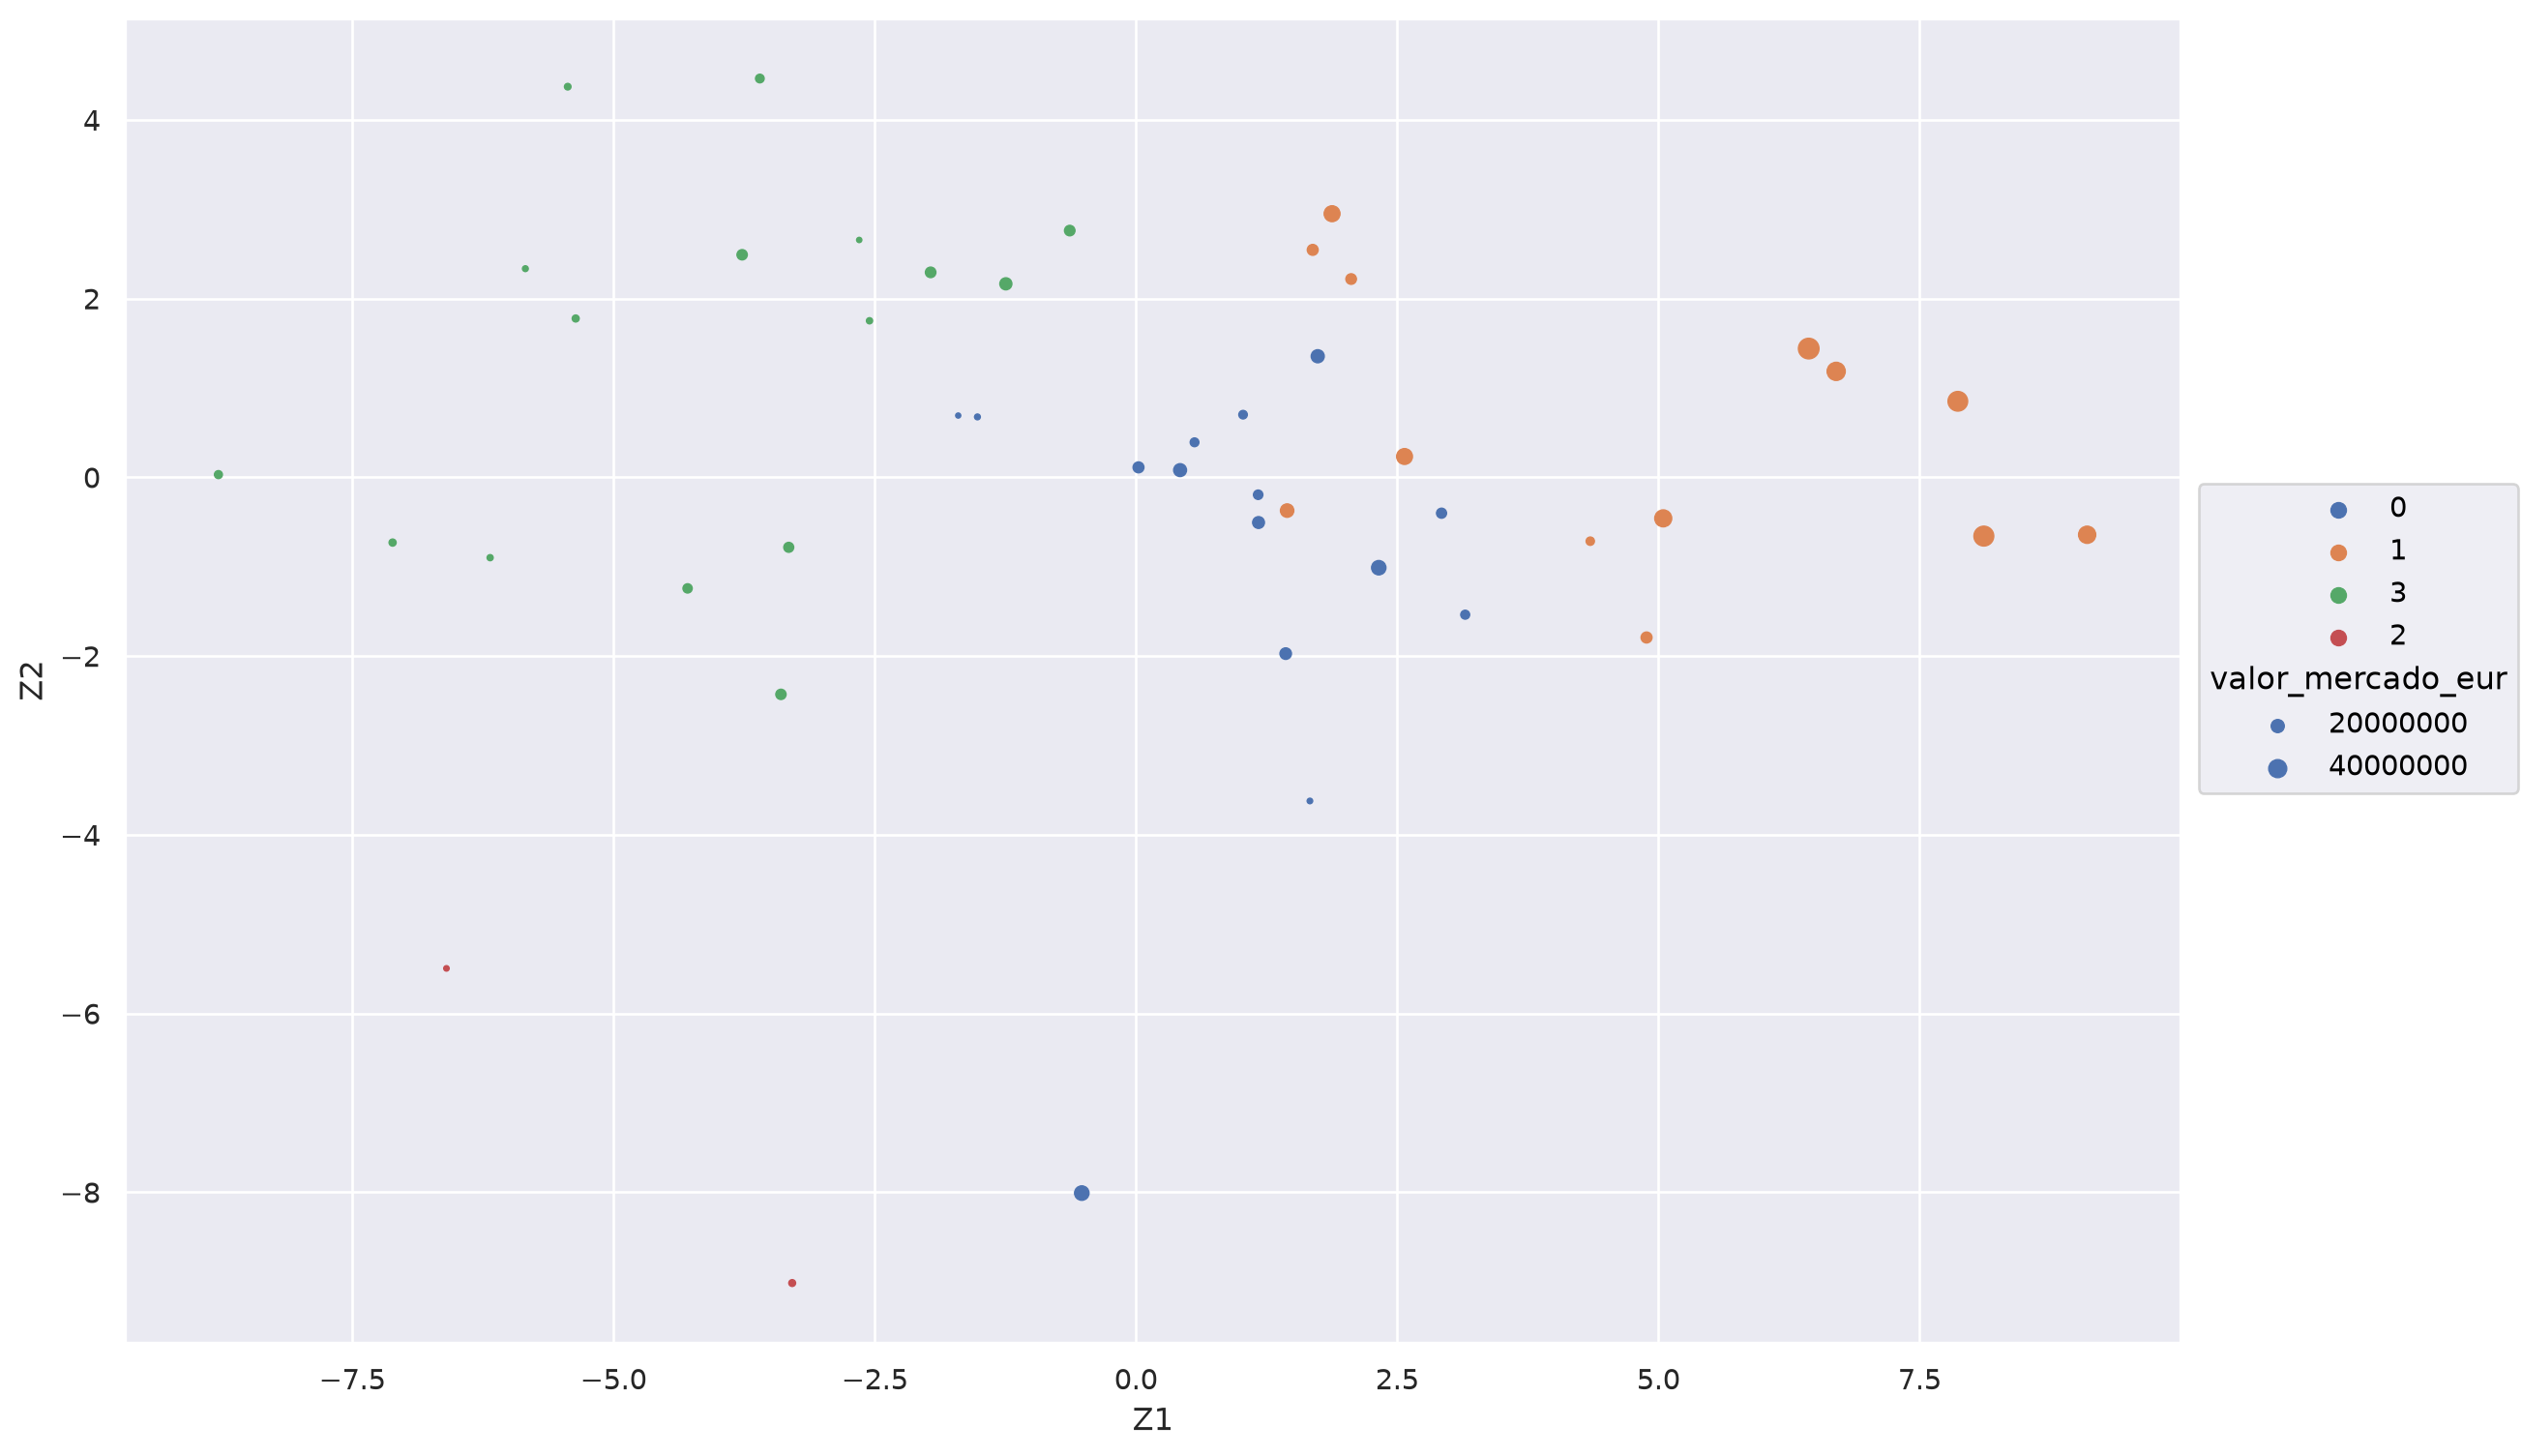

In [1170]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", color = cluster.astype(str), pointsize=df_selecciones["valor_mercado_eur"])
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

# Regresión y clasificación

## 1.

In [1171]:
df_jugadores_regresion = df_jugadores_limpia.copy()
df_jugadores_regresion["partidos_liga"] = df_jugadores_regresion["standard_playing_time_min"] / 90
df_jugadores_regresion

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,nat3,valor_mercado_eur,posicion_tm,rango_etario,partidos_liga
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,0.0,0.0,1.0,0.0,0.0,CZE,7000000.0,Goalkeeper,B,31.000000
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,0.0,4.0,40.0,17.0,0.0,CZE,4500000.0,Centre-Back,B,20.633333
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,1.0,22.0,44.0,24.0,0.0,CZE,2200000.0,Centre-Back,C,23.255556
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,0.0,6.0,20.0,15.0,0.0,CZE,5500000.0,Centre-Back,B,25.011111
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,1.0,209.0,39.0,35.0,0.0,CZE,7000000.0,Right-Back,C,33.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,1239,Panama,20,MF,Aníbal Godoy,1990-02-10,36,159,4,San Diego FC,...,0.0,3.0,16.0,14.0,0.0,PAN,200000.0,Defensive Midfield,C,19.077778
916,1240,Panama,21,MF,César Yanis,1996-01-28,30,56,5,Cobresal,...,4.0,39.0,24.0,13.0,0.0,PAN,250000.0,Right Winger,B,18.433333
917,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,0.0,0.0,0.0,0.0,1.0,PAN,350000.0,Goalkeeper,C,32.000000
918,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,2.0,29.0,6.0,8.0,0.0,PAN,7000000.0,Right-Back,B,10.644444


In [1172]:
df_jugadores_regresion.groupby("confederacion")["standard_playing_time_mp"].max()

confederacion
AFC         38.0
CAF         37.0
CONCACAF    37.0
CONMEBOL    38.0
OFC         32.0
UEFA        39.0
Name: standard_playing_time_mp, dtype: float64

## 2.

In [1173]:
from formulaic import Formula
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score

In [1174]:
y = df_jugadores_regresion["partidos_liga"]
X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero", "partidos_liga", "standard_playing_time_min"])
# X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero", "partidos_liga", "caps", "standard_playing_time_mp", "standard_playing_time_starts", "standard_playing_time_min", "standard_playing_time_90s", "shooting_90s", "misc_90s"])

In [1175]:
test_split = 0.3 # probe con 0.1 y 0.2 y funciona sustancialmente mejor con 0.3
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)

In [1176]:
def evaluacion_modelo_final(modelo):
	# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento.
	modelo.fit(X_train, y_train)

	# Predicciones
	y_pred = modelo.predict(X_test)

	# Bondad del ajuste
	r2 = r2_score(y_test, y_pred)
	print('R^2: ', r2)
	recm = root_mean_squared_error(y_test, y_pred)
	print('Raiz cuadrada del ECM: ', recm)

In [1177]:
modelo = LinearRegression(fit_intercept=False)    # Inicializamos un modelo de Regresion Lineal.

evaluacion_modelo_final(modelo)

R^2:  0.5268294016295358
Raiz cuadrada del ECM:  5.929580698529573


In [1178]:
alfas = [0, 0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1]

rmse_train = {}  # Resulta útil guardar los valores en un diccionario
rmse_test = {}
intercept = {}
for alfa in alfas:
	splits = 5
	cv = KFold(n_splits=splits, random_state=random_state, shuffle=True)
	rmse2_train = np.zeros(cv.get_n_splits())
	rmse2_test = np.zeros(cv.get_n_splits())
	ind = 0
	ridge = Ridge(alpha=alfa)

	for train_index, val_index in cv.split(X_train):
		X_train2, X_val, y_train2, y_val = X_train.iloc[train_index], X_train.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
		ridge.fit(X_train2, y_train2)
		rmse2_train[ind] = root_mean_squared_error(y_val, ridge.predict(X_val))
		rmse2_test[ind] = root_mean_squared_error(y_test, ridge.predict(X_test))
		ind += 1

	rmse_train[alfa] =  rmse2_train.mean()
	rmse_test[alfa] =  rmse2_test.mean()
	intercept[alfa] = ridge.intercept_

/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.145622990011805e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.3399200776673776e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9655233437021043e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

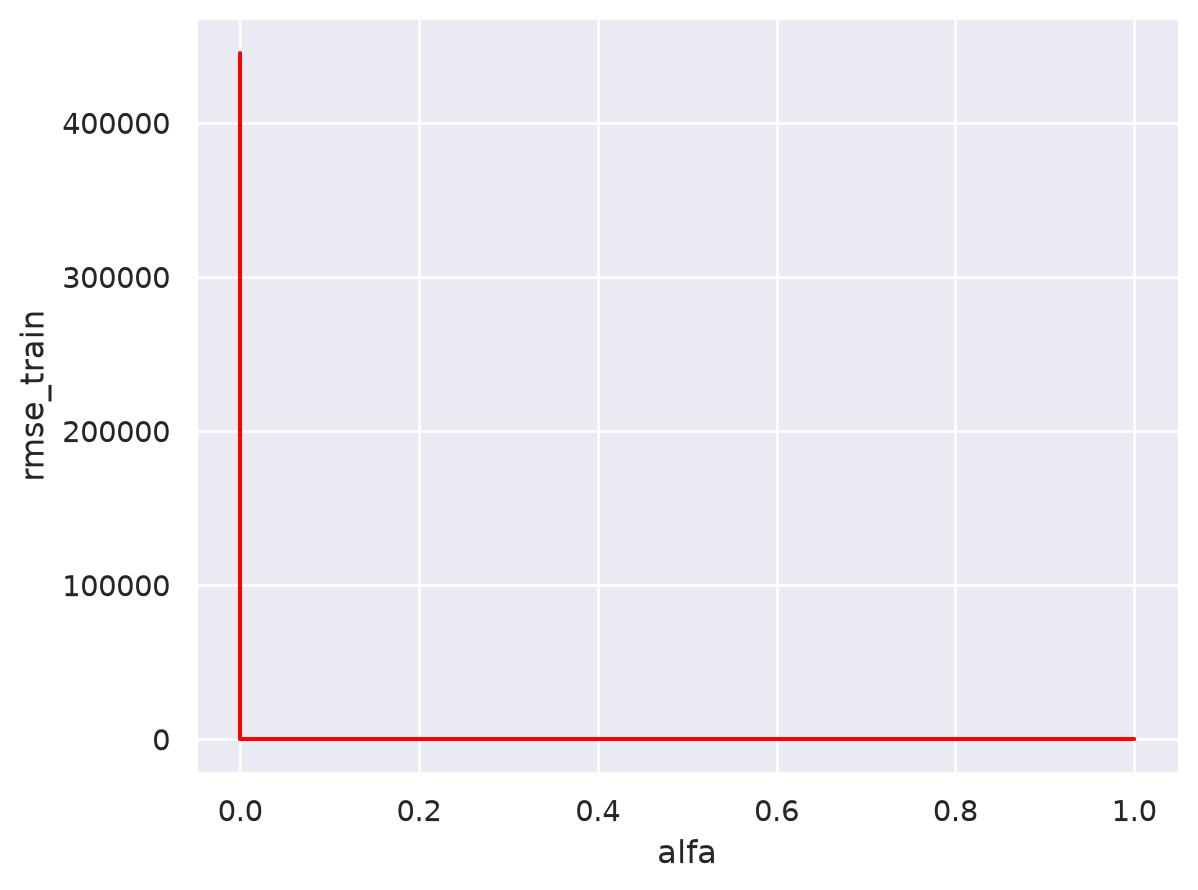

In [1179]:
# Convertimos a DataFrame para graficar
data = pd.DataFrame(
    {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "intercept": intercept,
    }
).reset_index(names="alfa")

# Graficamos los residuos en función de alfa
(
    so.Plot(data = data, x= "alfa")
    .add(so.Line(), y = "rmse_train")
    .add(so.Line(color = "red"), y = "rmse_test")
)

In [1180]:
alpha = data["alfa"][data["rmse_test"].idxmin()]
print("El valor de alfa que minimiza el RMSE en test es: ", alpha)

ridge = Ridge(alpha=alpha)
evaluacion_modelo_final(ridge)

El valor de alfa que minimiza el RMSE en test es:  0.001
R^2:  0.9909564063980872
Raiz cuadrada del ECM:  0.8197579318196251


/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7568435599655183e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [1181]:
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": alfas}
gs = GridSearchCV(
    Ridge(),
    param_grid,
    cv=splits,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
)

evaluacion_modelo_final(gs)
print("alpha: " + str(gs.best_params_['alpha']))

/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2878231478626393e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9440043027873937e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.7633946749903536e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

R^2:  0.9908840136183608
Raiz cuadrada del ECM:  0.8230324192424257
alpha: 1


/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7208641842692098e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [1182]:
modelo = RidgeCV(
    alphas = alfas,
    cv = 5,
    scoring="neg_root_mean_squared_error")
evaluacion_modelo_final(modelo)
print("alpha: " + str(modelo.alpha_))

/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2878231478626393e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9440043027873937e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.7633946749903536e-25.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

R^2:  0.9908840136183608
Raiz cuadrada del ECM:  0.8230324192424257
alpha: 1.0


/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0209237003286127e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2317866428127147e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.897331953290721e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/vinpalonsky/Desktop/tp-labo-de-datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

Los modelos lineales Ridge funcionan mucho mejor que los multivariado, obteniendo los primeros 0.9 de R2 y el segundo 0.5

## 3.

In [1183]:
# Utilizamos NearestNeighbors para obtener los vecinos más cercanos
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
# Cargamos el comando mode
import statistics
from statistics import mode
from sklearn.metrics import accuracy_score

In [1184]:
# Juntamos todo en una función
def mas_votado(datos, categorias, ind, K):

    # Eliminamos al propio jugador, para no incluirlo en los vecinos.
    datos2 = datos.drop(index=ind)
    categorias2 = categorias.drop(index=ind)

    # Tomamos K vecinos, porque ya eliminamos al propio jugador.
    neighbors = NearestNeighbors(n_neighbors=K)
    neighbors.fit(datos.drop([ind]))

    distances, indices = neighbors.kneighbors(datos.iloc[[ind]])
    votos = categorias2.iloc[indices.flatten()]

    # Los indices que devuelve kneighbors son posicion dentro del dataset (no indices del DF),
    # por eso tenemos que eliminar al pinguino[ind] de las categorias

    return(mode(votos))

In [1185]:
def knn_leave_one_out(datos, categorias, K):
    correctos = 0
    total = len(datos)
    for ind in range(total):
        prediccion = mas_votado(datos, categorias, ind, K)
        if(prediccion == categorias.iloc[ind]):
            correctos += 1
    return(correctos/total)

In [1186]:
df_jugadores_regresion["posicion"].unique()

<StringArray>
['GK', 'DF', 'MF', 'FW']
Length: 4, dtype: str

In [1187]:
df_jugadores_regresion["posicion_tm"].unique()

<StringArray>
[        'Goalkeeper',        'Centre-Back',         'Right-Back',
   'Central Midfield',     'Centre-Forward',          'Left-Back',
 'Attacking Midfield',        'Left Winger',     'Right Midfield',
 'Defensive Midfield',       'Right Winger',      'Left Midfield',
     'Second Striker']
Length: 13, dtype: str

In [1201]:
mapeo_posiciones = {
		"GK": 0,
		"DF": 1,
		"MF": 2,
		"FW": 3
}
y = df_jugadores_regresion["posicion"].map(mapeo_posiciones)
X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero"])

In [1202]:
# mapeo_posiciones_tm = {
# 	'Goalkeeper': 0,
# 	'Centre-Back': 1,
# 	'Right-Back': 2,
# 	'Central Midfield': 3,
# 	'Centre-Forward': 4,
# 	'Left-Back': 5,
# 	'Attacking Midfield': 6,
# 	'Left Winger': 7,
# 	'Right Midfield': 8,
# 	'Defensive Midfield': 9,
# 	'Right Winger': 10,
# 	'Left Midfield': 11,
# 	'Second Striker': 12
# }
# y = df_jugadores_regresion["posicion_tm"].map(mapeo_posiciones_tm)
# X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero"])

In [1203]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
for K in range(1,30,2):
	aciertos = knn_leave_one_out(X_scaled, y, K)
	print(K, aciertos)

1 0.6
3 0.633695652173913
5 0.6521739130434783
7 0.6684782608695652
9 0.6891304347826087
11 0.6760869565217391
13 0.6717391304347826
15 0.6826086956521739
17 0.6793478260869565
19 0.6728260869565217
21 0.6902173913043478
23 0.6891304347826087
25 0.6771739130434783
27 0.6793478260869565
29 0.6673913043478261


In [1204]:
test_split = 0.1
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)

In [1205]:
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1206]:
# Repetimos todo para varios valores de K
for K in range(1,30,2):
    neighbor = KNeighborsClassifier(n_neighbors=K)
    neighbor.fit(X_train_scaled,y_train)
    y_pred = neighbor.predict(X_test_scaled)

    print(K, accuracy_score(y_test,y_pred))

1 0.5434782608695652
3 0.6195652173913043
5 0.6195652173913043
7 0.6739130434782609
9 0.6195652173913043
11 0.6630434782608695
13 0.6630434782608695
15 0.6413043478260869
17 0.6304347826086957
19 0.6304347826086957
21 0.6304347826086957
23 0.6304347826086957
25 0.6521739130434783
27 0.6521739130434783
29 0.6521739130434783


Utilizando la variable posiciones_tm funciona considerablemente peor que utilizando posiciones

# El 11 ideal de Argentina y Brasil